# Notebook 5 — Model Evaluation & Explainability

Notebook 4 selected the final model. That model is now **frozen**.

This notebook does not try to make the model better. Instead, it evaluates the final model on the untouched test set and explains how it behaves.

We will answer four questions:

1. How well does the final model perform?
2. How much did it improve over the Notebook 3 baseline?
3. Where does it make its largest errors?
4. Which features does it rely on, and how do those features contribute to individual predictions?

The test set is used here for evaluation and explanation only. No tuning, model selection, new features, or preprocessing changes are made in this notebook.


---
## 1. Setup

### What are we doing?

Load the libraries and project settings needed for evaluation and explainability.

The final model and its preprocessing remain unchanged from Notebook 4.


In [ ]:
import json
import subprocess
import sys
import tempfile
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import sklearn
from sklearn.exceptions import InconsistentVersionWarning
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import train_test_split

print("pandas       ", pd.__version__)
print("numpy        ", np.__version__)
print("scikit-learn ", sklearn.__version__)

pandas        2.2.3
numpy         2.1.3
scikit-learn  1.6.1


In [ ]:
# The Notebook 4 model was pickled with scikit-learn 1.6.1. A pickled estimator is
# not portable across scikit-learn versions, so the notebook says what is needed
# instead of failing later on an obscure attribute error.
ARTIFACT_SKLEARN_VERSION = "1.6.1"

if sklearn.__version__ == ARTIFACT_SKLEARN_VERSION:
    print(f"scikit-learn {sklearn.__version__} matches the version that saved "
          f"04_final_model.joblib.")
else:
    print(f"WARNING: this kernel runs scikit-learn {sklearn.__version__}, but "
          f"04_final_model.joblib was saved with {ARTIFACT_SKLEARN_VERSION}.")
    print("If the model fails to load, install the matching versions and restart:")
    print("    pip install scikit-learn==1.6.1 pandas==2.2.3 numpy==2.1.3")

scikit-learn 1.6.1 matches the version that saved 04_final_model.joblib.


In [ ]:
# --- Configuration -------------------------------------------------------
RANDOM_STATE = 42

TARGET_NAME = "Expected_Retirement_Fund"
TEST_SIZE = 0.20                 # the Notebook 2 split proportion

DOLLAR_FLOOR = 1.0               # same floor Notebook 4 used before taking logs
REPRODUCTION_TOLERANCE = 1e-6    # relative, for matching the Notebook 4 metrics
RELOAD_TOLERANCE = 1e-6          # dollars, for the fresh-process reload test

PERMUTATION_REPEATS = 10         # kept small so the notebook stays quick to run
N_TOP_FEATURES = 15              # how many features the importance figures show
N_LARGEST_ERRORS = 10            # rows in the largest-error table

print(f"RANDOM_STATE        {RANDOM_STATE}")
print(f"PERMUTATION_REPEATS {PERMUTATION_REPEATS}")
print(f"Tolerances          reproduction {REPRODUCTION_TOLERANCE:g} (relative), "
      f"reload {RELOAD_TOLERANCE:g} ($)")

RANDOM_STATE        42
PERMUTATION_REPEATS 10
Tolerances          reproduction 1e-06 (relative), reload 1e-06 ($)


In [ ]:
# Same visual identity as Notebooks 1-4.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.edgecolor": "#CCCCCC",
    "grid.color": "#E8E8E8",
    "font.size": 10,
})

NAVY = "#1F3B73"
TEAL = "#2A9D8F"
AMBER = "#E9A13B"
CORAL = "#E76F51"
SLATE = "#6C757D"

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

In [ ]:
# The project root is the folder that holds retirement_dataset_v2.csv. Earlier
# notebooks keep their outputs in their own folders (3/artifacts, 4/artifacts),
# so each required file is located by searching the project tree once rather than
# assuming a single artifacts directory.
CANDIDATE_ROOTS = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
    Path("/content/Retirement-Readiness-Predictor"),
]

PROJECT_ROOT = None
for candidate in CANDIDATE_ROOTS:
    if candidate.exists() and any(candidate.rglob("retirement_dataset_v2.csv")):
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find the project root (the folder containing "
        "retirement_dataset_v2.csv). Checked: "
        + ", ".join(str(path) for path in CANDIDATE_ROOTS)
    )


def find_project_file(filename):
    """Return the path of one project file, searched for under PROJECT_ROOT."""
    matches = sorted(path for path in PROJECT_ROOT.rglob(filename)
                     if ".ipynb_checkpoints" not in path.parts)
    if not matches:
        raise FileNotFoundError(f"{filename} was not found under {PROJECT_ROOT}")
    return matches[0]


DATA_PATH = find_project_file("retirement_dataset_v2.csv")
FEATURE_ENGINEERING_PATH = find_project_file("feature_engineering.py")
FINAL_MODEL_PATH = find_project_file("04_final_model.joblib")
FINAL_CONFIG_PATH = find_project_file("04_final_model_config.json")
NOTEBOOK4_RESULTS_PATH = find_project_file("04_model_improvement_results.csv")
BASELINE_MODEL_PATH = find_project_file("03_baseline_model.joblib")
NOTEBOOK3_RESULTS_PATH = find_project_file("03_baseline_model_results.csv")

# src/feature_engineering.py must be importable, because the saved pipeline
# rebuilds its FunctionTransformer from that module.
SOURCE_ROOT = FEATURE_ENGINEERING_PATH.parent.parent
if str(SOURCE_ROOT) not in sys.path:
    sys.path.insert(0, str(SOURCE_ROOT))

from src.feature_engineering import add_engineered_features   # noqa: E402

# Notebook 5 writes its own outputs next to itself and leaves every earlier
# artifact untouched.
ARTIFACTS_DIR = Path.cwd() / "artifacts"
FIGURES_DIR = Path.cwd() / "figures"
ARTIFACTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Source root: ", SOURCE_ROOT)
for path in [DATA_PATH, FINAL_MODEL_PATH, FINAL_CONFIG_PATH,
             NOTEBOOK4_RESULTS_PATH, BASELINE_MODEL_PATH, NOTEBOOK3_RESULTS_PATH]:
    print(f"   {path.name:<38} {path.relative_to(PROJECT_ROOT)}")
print("Notebook 5 outputs ->", ARTIFACTS_DIR, "and", FIGURES_DIR)

Project root: /root/proj
Source root:  /root/proj/3
   retirement_dataset_v2.csv              retirement_dataset_v2.csv
   04_final_model.joblib                  4/artifacts/04_final_model.joblib
   04_final_model_config.json             4/artifacts/04_final_model_config.json
   04_model_improvement_results.csv       4/artifacts/04_model_improvement_results.csv
   03_baseline_model.joblib               3/artifacts/03_baseline_model.joblib
   03_baseline_model_results.csv          3/artifacts/03_baseline_model_results.csv
Notebook 5 outputs -> /root/proj/5/artifacts and /root/proj/5/figures


---
## 2. Load the Final Model and the Test Data

### What are we doing?

Load the final model selected in Notebook 4, its prediction configuration, and the same test set used for the final evaluation.

We are not creating a new test split. The goal is to evaluate the exact model on the exact customers that were kept aside during model development.


In [ ]:
try:
    final_model = joblib.load(FINAL_MODEL_PATH)
except (AttributeError, ImportError, ModuleNotFoundError) as error:
    raise RuntimeError(
        f"04_final_model.joblib could not be unpickled by scikit-learn "
        f"{sklearn.__version__}. It was saved with {ARTIFACT_SKLEARN_VERSION}. "
        f"Install that version (pip install scikit-learn==1.6.1 pandas==2.2.3 "
        f"numpy==2.1.3) and restart the kernel."
    ) from error

final_config = json.loads(FINAL_CONFIG_PATH.read_text())
gradient_boosting = final_model.named_steps["model"]

print("Candidate:      ", final_config["candidate"])
print("Target scale:   ", final_config["target_scale"])
print("Smearing:       ", final_config["smearing"],
      f"(factor {final_config['smearing_factor']:.6f})")
print("Age^2 variant:  ", final_config["age_squared"])
print("Pipeline steps: ", [name for name, _ in final_model.steps])
print()
print("Hyperparameters read from the fitted estimator:")
for key in ["n_estimators", "learning_rate", "max_depth",
            "min_samples_leaf", "subsample", "random_state"]:
    print(f"   {key:<18} {gradient_boosting.get_params()[key]}")
print()
print(f"Trees actually fitted: {gradient_boosting.n_estimators_}")
print(f"Features the estimator expects: {gradient_boosting.n_features_in_}")

# The saved configuration is the source of truth; the fitted object must agree.
for key, value in final_config["model_params"].items():
    assert gradient_boosting.get_params()[key] == value, f"{key} disagrees with the config."
assert gradient_boosting.get_params()["random_state"] == final_config["random_state"]
print("\nFitted model agrees with 04_final_model_config.json.")

Candidate:       Tuned GB (log + smearing)
Target scale:    log
Smearing:        True (factor 1.028933)
Age^2 variant:   False
Pipeline steps:  ['preprocess', 'model']

Hyperparameters read from the fitted estimator:
   n_estimators       600
   learning_rate      0.05
   max_depth          4
   min_samples_leaf   5
   subsample          0.8
   random_state       42

Trees actually fitted: 600
Features the estimator expects: 40

Fitted model agrees with 04_final_model_config.json.


### The Notebook 2 train/test split

Notebook 2 saved the training and test split in `artifacts/`.

If those files are available, this notebook uses them directly. If they are not available, the split is rebuilt using Notebook 2's exact deterministic recipe.

The next section checks the reconstructed result against the saved Notebook 4 result. This helps confirm that the same test customers are being evaluated.


In [ ]:
# Notebook 2's recipe, unchanged: drop identifiers, KPI columns and the target,
# remove exact duplicate records, then split 80/20 with random_state=42.
IDENTIFIER_COLUMNS = ["CustomerID"]
KPI_COLUMNS = ["Readiness_Score", "Funding_Gap", "RetirementReady"]

saved_test_features = sorted(PROJECT_ROOT.rglob("X_test.csv.gz"))
saved_test_target = sorted(PROJECT_ROOT.rglob("y_test.csv"))
saved_train_features = sorted(PROJECT_ROOT.rglob("X_train.csv.gz"))
SPLIT_SOURCE = ("saved Notebook 2 artifacts"
                if saved_test_features and saved_test_target and saved_train_features
                else "rebuilt from retirement_dataset_v2.csv")

if SPLIT_SOURCE == "saved Notebook 2 artifacts":
    X_train_raw = pd.read_csv(saved_train_features[0], index_col=0)
    X_test_raw = pd.read_csv(saved_test_features[0], index_col=0)
    y_test_all = pd.read_csv(saved_test_target[0], index_col=0)
    y_test_log = y_test_all.log_target
    y_test_dollars = y_test_all.target_dollars
else:
    raw_data = pd.read_csv(DATA_PATH)
    features = raw_data.drop(columns=IDENTIFIER_COLUMNS + KPI_COLUMNS + [TARGET_NAME])
    target = raw_data[TARGET_NAME]

    rows_to_keep = ~raw_data.duplicated(keep="first")
    features = features[rows_to_keep]
    target = target[rows_to_keep]

    X_train_raw, X_test_raw, _, y_test_target_dollars = train_test_split(
        features, target, test_size=TEST_SIZE, random_state=RANDOM_STATE,
    )
    y_test_dollars = y_test_target_dollars
    y_test_log = np.log(y_test_dollars)

test_actual_dollars = y_test_dollars.to_numpy()

print(f"Split source: {SPLIT_SOURCE}")
print(f"Training rows: {len(X_train_raw):,} x {X_train_raw.shape[1]} raw columns")
print(f"Test rows:     {len(X_test_raw):,} x {X_test_raw.shape[1]} raw columns")
print(f"Rows shared between training and test: "
      f"{len(X_test_raw.index.intersection(X_train_raw.index))}")
print(f"Raw columns identical: {list(X_test_raw.columns) == list(X_train_raw.columns)}")
print(f"Target strictly positive: {bool((test_actual_dollars > 0).all())}")

Split source: rebuilt from retirement_dataset_v2.csv
Training rows: 23,880 x 27 raw columns
Test rows:     5,970 x 27 raw columns
Rows shared between training and test: 0
Raw columns identical: True
Target strictly positive: True


In [ ]:
# The transformed matrix is what the Gradient Boosting estimator actually sees.
# The preprocessor was fitted in Notebook 2 and refitted in Notebook 4 on the
# training rows; here it only transforms, so nothing is relearned.
preprocessor = final_model[:-1]
X_train_transformed = preprocessor.transform(X_train_raw)
X_test_transformed = preprocessor.transform(X_test_raw)
model_feature_names = list(X_test_transformed.columns)

print(f"X_train_transformed {X_train_transformed.shape}")
print(f"X_test_transformed  {X_test_transformed.shape}")
print(f"Model features: {len(model_feature_names)} "
      f"(config expects {final_config['n_model_features']})")
print()
print("First 10 feature names: ", ", ".join(model_feature_names[:10]))
print("Last 10 feature names:  ", ", ".join(model_feature_names[-10:]))

assert len(model_feature_names) == final_config["n_model_features"]
assert list(X_train_transformed.columns) == list(X_test_transformed.columns)
assert int(X_test_transformed.isna().sum().sum()) == 0
assert bool(np.isfinite(X_test_transformed.to_numpy()).all())
print("\nTransformed test matrix is complete, finite and matches the configuration.")

X_train_transformed (23880, 40)
X_test_transformed  (5970, 40)
Model features: 40 (config expects 40)

First 10 feature names:  Age, NumberOfChildren, AnnualSalary, AnnualBonus, Savings, CheckingBalance, EmergencyFund, InvestmentBalance, RetirementAccountBalance, Debt
Last 10 feature names:   MaritalStatus_Single, MaritalStatus_Widowed, EmploymentStatus_Part-time, EmploymentStatus_Self-employed, EmploymentStatus_Unemployed, OwnHouse_Yes, FinancialKnowledge_High, FinancialKnowledge_Low, FinancialKnowledge_Moderate, EmployerPension_Yes

Transformed test matrix is complete, finite and matches the configuration.


---
## 3. Reproduce the Notebook 4 Test Result

### What are we doing?

Generate the final model's predictions from the saved model instead of copying the numbers reported by Notebook 4.

The saved prediction recipe is:

1. predict the target in log space;
2. convert the prediction back to dollars with `exp()`;
3. apply the saved smearing factor.

We then calculate the same evaluation metrics used in Notebook 4.

### Why?

A reproducible project should be able to load the saved model and recover the same result later.


In [ ]:
def predict_dollars(model, X_raw, config):
    """Turn a fitted pipeline's output into dollars, following the saved recipe."""
    predictions = model.predict(X_raw)
    if config["target_scale"] == "log":
        predictions = np.exp(predictions) * config["smearing_factor"]
    return predictions


def score_predictions(name, actual_dollars, predicted_dollars):
    """The Notebook 4 metric set, computed from dollar predictions."""
    actual_dollars = np.asarray(actual_dollars, dtype=float)
    predicted_dollars = np.asarray(predicted_dollars, dtype=float)

    actual_log = np.log(actual_dollars)
    predicted_log = np.log(np.clip(predicted_dollars, DOLLAR_FLOOR, None))

    return {
        "Candidate": name,
        "R2 (log)": r2_score(actual_log, predicted_log),
        "RMSE (log)": np.sqrt(mean_squared_error(actual_log, predicted_log)),
        "MAE (log)": mean_absolute_error(actual_log, predicted_log),
        "R2 ($)": r2_score(actual_dollars, predicted_dollars),
        "RMSE ($)": np.sqrt(mean_squared_error(actual_dollars, predicted_dollars)),
        "MAE ($)": mean_absolute_error(actual_dollars, predicted_dollars),
        "MedianAE ($)": median_absolute_error(actual_dollars, predicted_dollars),
        "MAPE (%)": np.mean(np.abs((actual_dollars - predicted_dollars) / actual_dollars)) * 100,
        "Aggregate bias (%)": (predicted_dollars.mean() / actual_dollars.mean() - 1) * 100,
    }


final_test_dollars = predict_dollars(final_model, X_test_raw, final_config)
final_test_log = np.log(np.clip(final_test_dollars, DOLLAR_FLOOR, None))
final_test_scores = score_predictions(final_config["candidate"],
                                      test_actual_dollars, final_test_dollars)

print(f"Predicted {len(final_test_dollars):,} test customers")
print(f"NaN predictions:      {int(np.isnan(final_test_dollars).sum())}")
print(f"Infinite predictions: {int(np.isinf(final_test_dollars).sum())}")
print(f"Non-positive:         {int((final_test_dollars <= 0).sum())}")
print()
print(pd.Series(final_test_scores).drop("Candidate").to_string(
    float_format=lambda value: f"{value:,.6f}"))

Predicted 5,970 test customers
NaN predictions:      0
Infinite predictions: 0
Non-positive:         0

R2 (log)                     0.902230
RMSE (log)                   0.273068
MAE (log)                    0.197185
R2 ($)                       0.851462
RMSE ($)             1,231,162.935763
MAE ($)                753,165.483578
MedianAE ($)           436,661.804406
MAPE (%)                    21.014661
Aggregate bias (%)          -1.052576


In [ ]:
# Compare with what Notebook 4 recorded. The numbers are read from the file, and
# the differences are calculated.
notebook4_results = pd.read_csv(NOTEBOOK4_RESULTS_PATH, index_col=0)
notebook4_final_row = notebook4_results[
    (notebook4_results.Stage == "Test set")
    & (notebook4_results.index.str.startswith("Final:"))
].iloc[0]

METRIC_NAMES = ["R2 (log)", "RMSE (log)", "MAE (log)", "R2 ($)", "RMSE ($)",
                "MAE ($)", "MedianAE ($)", "MAPE (%)", "Aggregate bias (%)"]

reproduction = pd.DataFrame([
    {
        "metric": metric,
        "Notebook 4 recorded": float(notebook4_final_row[metric]),
        "reproduced here": final_test_scores[metric],
        "relative difference": abs(final_test_scores[metric] / float(notebook4_final_row[metric]) - 1),
    }
    for metric in METRIC_NAMES
]).set_index("metric")

print(reproduction.to_string(float_format=lambda value: f"{value:,.10f}"))

largest_reproduction_gap = reproduction["relative difference"].max()
print(f"\nLargest relative difference: {largest_reproduction_gap:.3e}")
print(f"Tolerance:                   {REPRODUCTION_TOLERANCE:g}")

assert largest_reproduction_gap <= REPRODUCTION_TOLERANCE, (
    "The reproduced test metrics do not match Notebook 4 within tolerance."
)
print("\nNotebook 4's test result is reproduced.")

                    Notebook 4 recorded      reproduced here  relative difference
metric                                                                           
R2 (log)                   0.9022304463         0.9022304463         0.0000000000
RMSE (log)                 0.2730680413         0.2730680413         0.0000000000
MAE (log)                  0.1971846930         0.1971846930         0.0000000000
R2 ($)                     0.8514617030         0.8514617030         0.0000000000
RMSE ($)           1,231,162.9357634897 1,231,162.9357634895         0.0000000000
MAE ($)              753,165.4835779198   753,165.4835779198         0.0000000000
MedianAE ($)         436,661.8044063473   436,661.8044063473         0.0000000000
MAPE (%)                  21.0146611443        21.0146611443         0.0000000000
Aggregate bias (%)        -1.0525758503        -1.0525758503         0.0000000000

Largest relative difference: 2.220e-16
Tolerance:                   1e-06

Notebook 4's test resu

---
## 4. Baseline vs Final Model

### What are we doing?

Compare the original Gradient Boosting baseline from Notebook 3 with the final model from Notebook 4 on the same test customers.

The comparison uses the same metric definitions for both models.

### Why?

Notebook 4 showed that tuning and the smearing correction improved the baseline. This section measures that improvement directly.

All changes are calculated from the actual predictions; no improvement percentage is entered manually.


In [ ]:
# 03_baseline_model.joblib was saved by a later scikit-learn version than the one
# this notebook runs on. The load is allowed, and the check underneath confirms it
# reproduced the figures Notebook 3 recorded.
with warnings.catch_warnings(record=True) as version_warnings:
    warnings.simplefilter("always", InconsistentVersionWarning)
    baseline_model = joblib.load(BASELINE_MODEL_PATH)

baseline_pickled_with = sklearn.__version__
for raised in version_warnings:
    if isinstance(raised.message, InconsistentVersionWarning):
        baseline_pickled_with = raised.message.original_sklearn_version
        break

baseline_test_dollars = np.exp(baseline_model.predict(X_test_raw))
baseline_test_log = np.log(np.clip(baseline_test_dollars, DOLLAR_FLOOR, None))
baseline_test_scores = score_predictions("Baseline GB (Notebook 3)",
                                         test_actual_dollars, baseline_test_dollars)

baseline_params = baseline_model.named_steps["model"].get_params()
print("Notebook 3 baseline hyperparameters:",
      {key: baseline_params[key] for key in ["n_estimators", "learning_rate", "max_depth"]})
print(f"Pickled by scikit-learn {baseline_pickled_with}, loaded by {sklearn.__version__}")

# Does the loaded baseline still reproduce the Notebook 3 results file?
notebook3_results = pd.read_csv(NOTEBOOK3_RESULTS_PATH, index_col=0)
notebook3_test_row = notebook3_results[notebook3_results.Stage == "Test set"].iloc[0]
notebook3_pairs = [("RMSE (log)", "RMSE (log)"), ("MAE (log)", "MAE (log)"),
                   ("RMSE ($)", "RMSE ($)"), ("MAE ($)", "MAE ($)"),
                   ("MAPE (%)", "MAPE (%)")]

baseline_check = pd.DataFrame([
    {"metric": here,
     "Notebook 3 file": float(notebook3_test_row[there]),
     "recomputed here": baseline_test_scores[here],
     "difference (%)": (baseline_test_scores[here] / float(notebook3_test_row[there]) - 1) * 100}
    for here, there in notebook3_pairs
]).set_index("metric")

print()
print(baseline_check.to_string(float_format=lambda value: f"{value:,.6f}"))
baseline_drift = baseline_check["difference (%)"].abs().max()
print(f"\nLargest disagreement with the Notebook 3 results file: {baseline_drift:.6f}%")
assert baseline_drift < 1.0, "The reloaded baseline disagrees with Notebook 3 by more than 1%."

Notebook 3 baseline hyperparameters: {'n_estimators': 300, 'learning_rate': 0.1, 'max_depth': 3}
Pickled by scikit-learn 1.8.0, loaded by 1.6.1

            Notebook 3 file  recomputed here  difference (%)
metric                                                      
RMSE (log)         0.281392         0.281392        0.000144
MAE (log)          0.203011         0.203011        0.000018
RMSE ($)   1,266,265.188427 1,266,265.188427       -0.000000
MAE ($)      769,676.528619   769,676.528619       -0.000000
MAPE (%)          21.282822        21.282822       -0.000001

Largest disagreement with the Notebook 3 results file: 0.000144%


In [ ]:
# The recorded Notebook 4 baseline row was produced by an earlier copy of
# 03_baseline_model.joblib. Reporting the gap rather than hiding it.
notebook4_baseline_row = notebook4_results[
    (notebook4_results.Stage == "Test set")
    & (notebook4_results.index == "Baseline GB (Notebook 3)")
].iloc[0]

print("Baseline dollar RMSE from three sources:")
print(f"   03_baseline_model_results.csv          ${float(notebook3_test_row['RMSE ($)']):>14,.2f}")
print(f"   recomputed here from the saved model   ${baseline_test_scores['RMSE ($)']:>14,.2f}")
print(f"   04_model_improvement_results.csv       ${float(notebook4_baseline_row['RMSE ($)']):>14,.2f}")
print(f"\nGap between the recomputed baseline and the Notebook 4 record: "
      f"{baseline_test_scores['RMSE ($)'] / float(notebook4_baseline_row['RMSE ($)']) - 1:+.4%}")
print("The comparison below uses the recomputed baseline, so both rows come from")
print("predictions generated in this notebook on the same test set.")

Baseline dollar RMSE from three sources:
   03_baseline_model_results.csv          $  1,266,265.19
   recomputed here from the saved model   $  1,266,265.19
   04_model_improvement_results.csv       $  1,265,982.71

Gap between the recomputed baseline and the Notebook 4 record: +0.0223%
The comparison below uses the recomputed baseline, so both rows come from
predictions generated in this notebook on the same test set.


In [ ]:
comparison_metrics = ["RMSE ($)", "MAE ($)", "MedianAE ($)", "MAPE (%)",
                      "RMSE (log)", "MAE (log)", "R2 (log)", "R2 ($)"]
LOWER_IS_BETTER = {"RMSE ($)", "MAE ($)", "MedianAE ($)", "MAPE (%)",
                   "RMSE (log)", "MAE (log)"}

improvement_rows = []
for metric in comparison_metrics:
    before = baseline_test_scores[metric]
    after = final_test_scores[metric]
    improvement_rows.append({
        "metric": metric,
        "Notebook 3 baseline": before,
        "Notebook 4 final": after,
        "absolute change": after - before,
        "change (%)": (after / before - 1) * 100,
        "better?": ((after < before) if metric in LOWER_IS_BETTER else (after > before)),
    })

improvements = pd.DataFrame(improvement_rows).set_index("metric")
print(improvements.to_string(float_format=lambda value: f"{value:,.4f}"))

print(f"\nRMSE ($) improvement:       {-improvements.loc['RMSE ($)', 'change (%)']:.2f}%")
print(f"MAE ($) improvement:        {-improvements.loc['MAE ($)', 'change (%)']:.2f}%")
print(f"MedianAE ($) improvement:   {-improvements.loc['MedianAE ($)', 'change (%)']:.2f}%")
print(f"MAPE change:                {improvements.loc['MAPE (%)', 'absolute change']:+.2f} "
      f"percentage points")
print(f"R2 (log) change:            {improvements.loc['R2 (log)', 'absolute change']:+.4f}")
print(f"Aggregate bias:             {baseline_test_scores['Aggregate bias (%)']:+.2f}% "
      f"-> {final_test_scores['Aggregate bias (%)']:+.2f}%")

              Notebook 3 baseline  Notebook 4 final  absolute change  change (%)  better?
metric                                                                                   
RMSE ($)           1,266,265.1884    1,231,162.9358     -35,102.2527     -2.7721     True
MAE ($)              769,676.5286      753,165.4836     -16,511.0450     -2.1452     True
MedianAE ($)         448,701.0896      436,661.8044     -12,039.2852     -2.6831     True
MAPE (%)                  21.2828           21.0147          -0.2682     -1.2600     True
RMSE (log)                 0.2814            0.2731          -0.0083     -2.9583     True
MAE (log)                  0.2030            0.1972          -0.0058     -2.8700     True
R2 (log)                   0.8962            0.9022           0.0061      0.6753     True
R2 ($)                     0.8429            0.8515           0.0086      1.0192     True

RMSE ($) improvement:       2.77%
MAE ($) improvement:        2.15%
MedianAE ($) improvement:   2.6

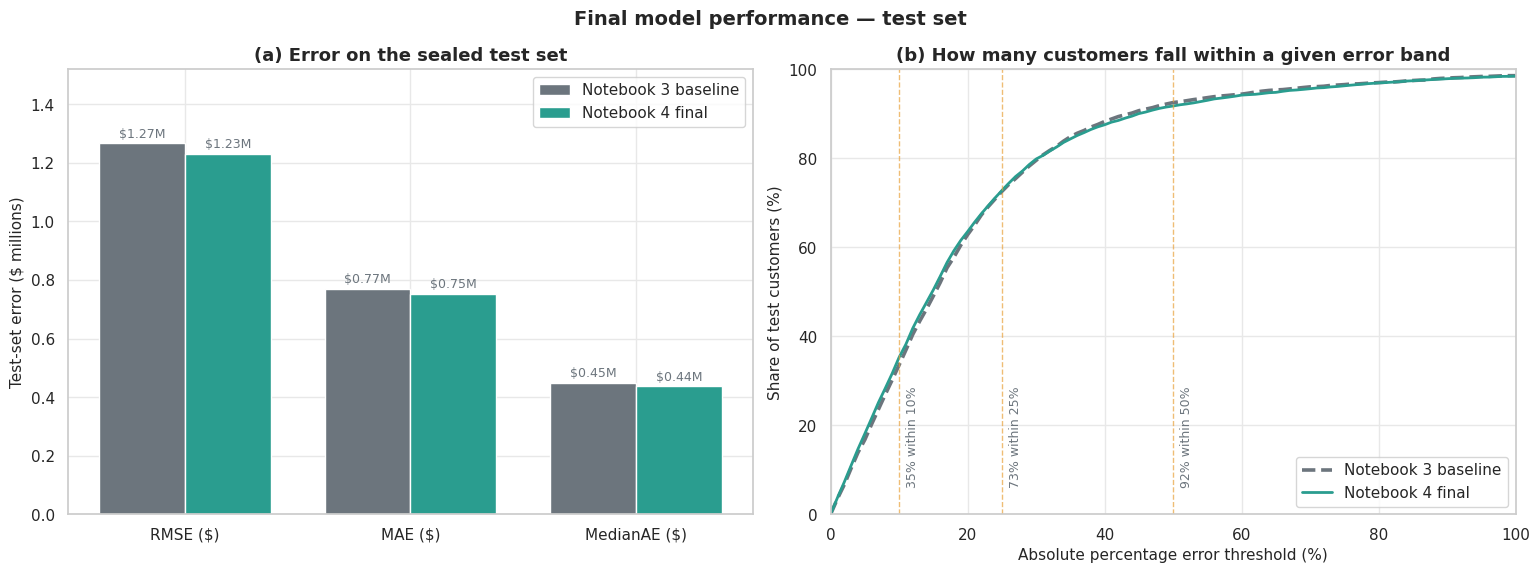

In [ ]:
# --- FIGURE 1: final model performance summary ---------------------------
final_absolute_percentage = np.abs(final_test_dollars - test_actual_dollars) / test_actual_dollars * 100
baseline_absolute_percentage = np.abs(baseline_test_dollars - test_actual_dollars) / test_actual_dollars * 100

fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.8))

dollar_metrics = ["RMSE ($)", "MAE ($)", "MedianAE ($)"]
baseline_values = [baseline_test_scores[metric] / 1e6 for metric in dollar_metrics]
final_values = [final_test_scores[metric] / 1e6 for metric in dollar_metrics]
offsets = np.arange(len(dollar_metrics))

axes[0].bar(offsets - 0.19, baseline_values, width=0.38, color=SLATE,
            edgecolor="white", label="Notebook 3 baseline")
axes[0].bar(offsets + 0.19, final_values, width=0.38, color=TEAL,
            edgecolor="white", label="Notebook 4 final")
axes[0].set_xticks(offsets)
axes[0].set_xticklabels(dollar_metrics)
axes[0].set_ylabel("Test-set error ($ millions)")
axes[0].set_title("(a) Error on the sealed test set")
for offset, before, after in zip(offsets, baseline_values, final_values):
    axes[0].text(offset - 0.19, before + 0.02, f"${before:.2f}M", ha="center",
                 fontsize=9, color=SLATE)
    axes[0].text(offset + 0.19, after + 0.02, f"${after:.2f}M", ha="center",
                 fontsize=9, color=SLATE)
axes[0].set_ylim(0, max(baseline_values + final_values) * 1.2)
axes[0].legend(frameon=True)

thresholds = np.arange(0, 101, 1)
baseline_share = [(baseline_absolute_percentage <= cut).mean() * 100 for cut in thresholds]
final_share = [(final_absolute_percentage <= cut).mean() * 100 for cut in thresholds]

# The two curves nearly coincide, so the baseline is dashed to stay visible.
axes[1].plot(thresholds, baseline_share, color=SLATE, lw=2.6, ls="--",
             label="Notebook 3 baseline")
axes[1].plot(thresholds, final_share, color=TEAL, lw=2, label="Notebook 4 final")
for cut in [10, 25, 50]:
    axes[1].axvline(cut, color=AMBER, lw=1, ls="--", alpha=0.7)
    axes[1].text(cut + 1, 6, f"{(final_absolute_percentage <= cut).mean() * 100:.0f}% within {cut}%",
                 fontsize=9, color=SLATE, rotation=90, va="bottom")
axes[1].set_xlabel("Absolute percentage error threshold (%)")
axes[1].set_ylabel("Share of test customers (%)")
axes[1].set_title("(b) How many customers fall within a given error band")
axes[1].set_xlim(0, 100)
axes[1].set_ylim(0, 100)
axes[1].legend(loc="lower right", frameon=True)

fig.suptitle("Final model performance — test set", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_final_model_summary.png", dpi=300, bbox_inches="tight",
            facecolor="white")
plt.show()

---
## 5. Prediction Diagnostics

### What are we looking for?

Compare each predicted retirement fund with the customer's actual fund.

The diagonal line is a **reference line**, not another model. It represents:

`predicted = actual`

A point on the line is a perfect prediction. Points above or below the line show the direction and size of the prediction error.

The further a point is from the line, the larger the prediction error.


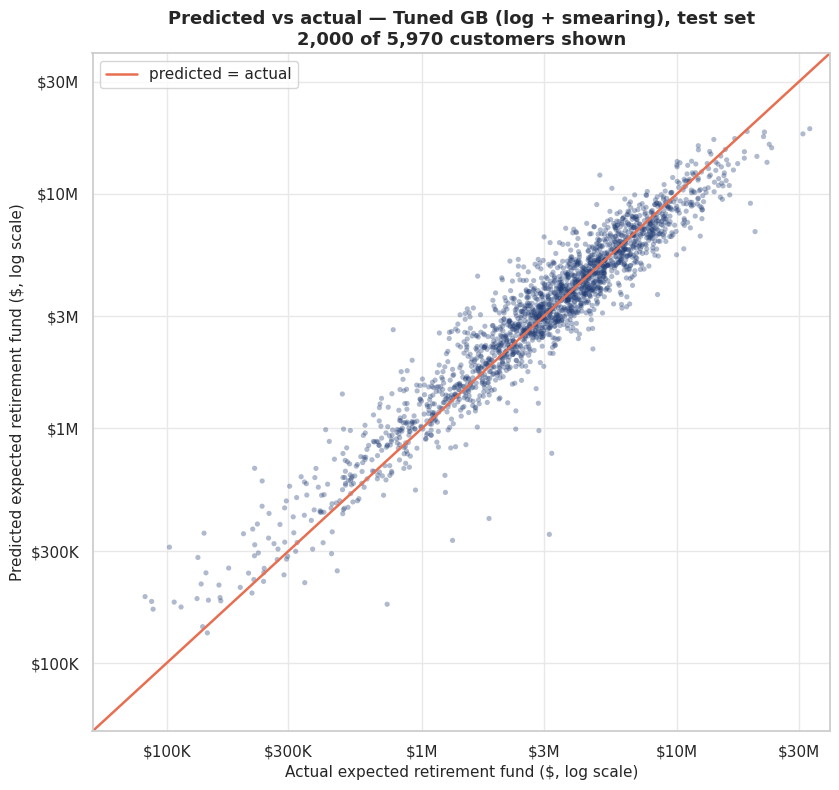

In [ ]:
# --- FIGURE 2: predicted vs actual ---------------------------------------
plot_sample = pd.DataFrame({
    "actual": test_actual_dollars,
    "predicted": final_test_dollars,
}).sample(2000, random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(8.5, 8))
ax.scatter(plot_sample.actual, plot_sample.predicted, s=14, alpha=0.35,
           color=NAVY, edgecolors="none")

limits = [test_actual_dollars.min() * 0.8, test_actual_dollars.max() * 1.2]
ax.plot(limits, limits, color=CORAL, lw=1.8, label="predicted = actual")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(limits)
ax.set_ylim(limits)
ax.set_xlabel("Actual expected retirement fund ($, log scale)")
ax.set_ylabel("Predicted expected retirement fund ($, log scale)")
ax.set_title(f"Predicted vs actual — {final_config['candidate']}, test set\n"
             f"2,000 of {len(test_actual_dollars):,} customers shown")

tick_values = [1e5, 3e5, 1e6, 3e6, 1e7, 3e7]
tick_labels = ["$100K", "$300K", "$1M", "$3M", "$10M", "$30M"]
ax.set_xticks(tick_values)
ax.set_xticklabels(tick_labels)
ax.set_yticks(tick_values)
ax.set_yticklabels(tick_labels)
ax.legend(loc="upper left", frameon=True)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_predicted_vs_actual.png", dpi=300, bbox_inches="tight",
            facecolor="white")
plt.show()

---
## 6. Residual Analysis

### What is a residual?

Here we define:

`residual = actual - predicted`

The residuals are examined in log space. This puts customers with very different fund sizes on a more comparable scale.

- **Positive residual:** the actual fund is higher than the prediction.
- **Negative residual:** the actual fund is lower than the prediction.
- **Residual near zero:** prediction and actual value are close on the log scale.

### What are we checking?

We are looking for patterns in the residuals that a single score cannot show, such as systematic over- or under-prediction, changing error size, or unusual observations.


In [ ]:
residuals_log = y_test_log.to_numpy() - final_test_log
residuals_dollars = test_actual_dollars - final_test_dollars

print("Residuals in log space")
print(f"   mean               {residuals_log.mean():+.6f}")
print(f"   median             {np.median(residuals_log):+.6f}")
print(f"   standard deviation {residuals_log.std(ddof=1):.6f}")
print(f"   skewness           {pd.Series(residuals_log).skew():+.4f}")
print(f"   share positive     {(residuals_log > 0).mean() * 100:.1f}%")
print()
print("Residuals in dollars")
print(f"   mean               ${residuals_dollars.mean():>14,.0f}")
print(f"   median             ${np.median(residuals_dollars):>14,.0f}")
print(f"   share positive     {(residuals_dollars > 0).mean() * 100:.1f}%")
print()
print(f"Mean actual    ${test_actual_dollars.mean():>14,.0f}")
print(f"Mean predicted ${final_test_dollars.mean():>14,.0f}")
print(f"Aggregate difference between the two means: "
      f"{final_test_scores['Aggregate bias (%)']:+.2f}%")

Residuals in log space
   mean               -0.028404
   median             -0.018647
   standard deviation 0.271610
   skewness           +0.4542
   share positive     46.4%

Residuals in dollars
   mean               $        42,757
   median             $       -40,090
   share positive     46.4%

Mean actual    $     4,062,102
Mean predicted $     4,019,345
Aggregate difference between the two means: -1.05%


In [ ]:
# Residuals by predicted quintile: does the pattern change across the range?
quintile_labels = ["1 (lowest)", "2", "3", "4", "5 (highest)"]
predicted_quintile = pd.qcut(final_test_log, 5, labels=quintile_labels)

residual_by_quintile = pd.DataFrame({
    "residual": residuals_log,
    "quintile": predicted_quintile,
    "predicted_dollars": final_test_dollars,
}).groupby("quintile", observed=True).agg(
    customers=("residual", "size"),
    median_predicted=("predicted_dollars", "median"),
    mean_residual=("residual", "mean"),
    median_residual=("residual", "median"),
    sd_residual=("residual", "std"),
)

print("Residuals by predicted quintile (log space):")
print(residual_by_quintile.to_string(float_format=lambda value: f"{value:,.4f}"))
print()
print("Reading: a positive mean residual means actual values in that band tend to")
print("sit above the prediction; a negative mean means predictions sit above actuals.")
print(f"Residual spread (SD), highest quintile / lowest quintile: "
      f"{residual_by_quintile.sd_residual.iloc[-1] / residual_by_quintile.sd_residual.iloc[0]:.2f}")

Residuals by predicted quintile (log space):
             customers  median_predicted  mean_residual  median_residual  sd_residual
quintile                                                                             
1 (lowest)        1194      996,602.7897        -0.0388          -0.0472       0.3554
2                 1194    2,275,039.8742        -0.0386          -0.0212       0.2536
3                 1194    3,429,058.2615        -0.0326          -0.0177       0.2413
4                 1194    4,885,420.7244        -0.0233          -0.0122       0.2403
5 (highest)       1194    7,690,736.8318        -0.0087           0.0005       0.2488

Reading: a positive mean residual means actual values in that band tend to
sit above the prediction; a negative mean means predictions sit above actuals.
Residual spread (SD), highest quintile / lowest quintile: 0.70


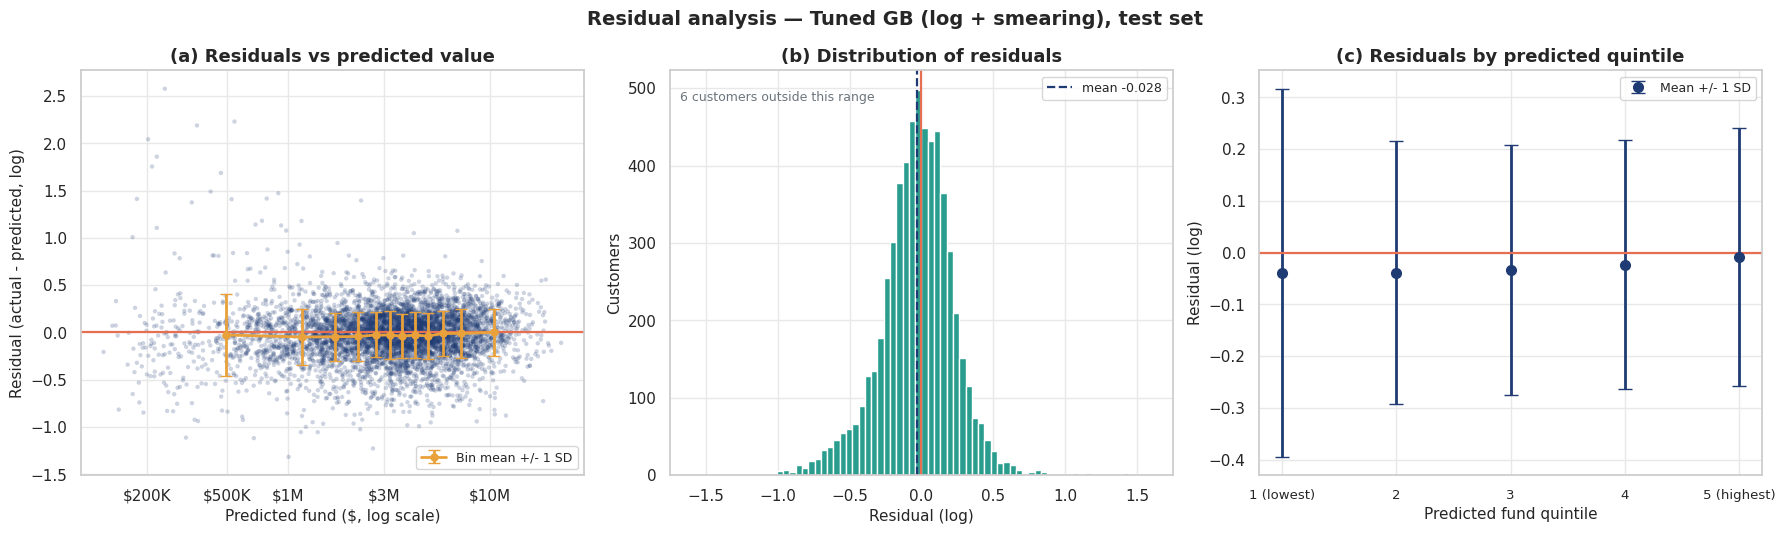

In [ ]:
# --- FIGURE 3: residual analysis -----------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5.4))

axes[0].scatter(final_test_log, residuals_log, s=10, alpha=0.22, color=NAVY,
                edgecolors="none")
axes[0].axhline(0, color=CORAL, lw=1.6)

bin_index = pd.qcut(final_test_log, 12, labels=False)
binned = pd.DataFrame({
    "prediction": final_test_log, "residual": residuals_log, "bin": bin_index,
}).groupby("bin", observed=True).agg(
    centre=("prediction", "mean"),
    mean_residual=("residual", "mean"),
    spread=("residual", "std"),
)
axes[0].errorbar(binned.centre, binned.mean_residual, yerr=binned.spread,
                 color=AMBER, lw=2, marker="o", markersize=5, capsize=4,
                 label="Bin mean +/- 1 SD")
axes[0].set_xticks(np.log([2e5, 5e5, 1e6, 3e6, 1e7]))
axes[0].set_xticklabels(["$200K", "$500K", "$1M", "$3M", "$10M"])
axes[0].set_xlabel("Predicted fund ($, log scale)")
axes[0].set_ylabel("Residual (actual - predicted, log)")
axes[0].set_title("(a) Residuals vs predicted value")
axes[0].legend(loc="lower right", frameon=True, fontsize=9)

axes[1].hist(residuals_log, bins=80, range=(-1.75, 1.75), color=TEAL,
             edgecolor="white")
axes[1].axvline(0, color=CORAL, lw=1.6)
axes[1].axvline(residuals_log.mean(), color=NAVY, lw=1.6, ls="--",
                label=f"mean {residuals_log.mean():+.3f}")
axes[1].set_xlim(-1.75, 1.75)
axes[1].set_xlabel("Residual (log)")
axes[1].set_ylabel("Customers")
axes[1].set_title("(b) Distribution of residuals")
axes[1].text(0.02, 0.95,
             f"{int((np.abs(residuals_log) > 1.75).sum())} customers outside this range",
             transform=axes[1].transAxes, fontsize=9, color=SLATE, va="top")
axes[1].legend(loc="upper right", frameon=True, fontsize=9)

positions = np.arange(len(residual_by_quintile))
axes[2].errorbar(positions, residual_by_quintile.mean_residual,
                 yerr=residual_by_quintile.sd_residual, color=NAVY, lw=0,
                 elinewidth=2, marker="o", markersize=7, capsize=5,
                 label="Mean +/- 1 SD")
axes[2].axhline(0, color=CORAL, lw=1.6)
axes[2].set_xticks(positions)
axes[2].set_xticklabels(residual_by_quintile.index, fontsize=9.5)
axes[2].set_xlabel("Predicted fund quintile")
axes[2].set_ylabel("Residual (log)")
axes[2].set_title("(c) Residuals by predicted quintile")
axes[2].legend(frameon=True, fontsize=9)

fig.suptitle(f"Residual analysis — {final_config['candidate']}, test set",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_residual_analysis.png", dpi=300, bbox_inches="tight",
            facecolor="white")
plt.show()

---
## 7. Error Analysis

### What are we doing?

Calculate prediction errors for each test customer and then examine those errors across the same groups used in Notebooks 3 and 4.

The main groups are:

- income quintile;
- years until retirement;
- predicted retirement fund size.

### Why?

A model can have a good overall score while performing differently for different groups.

This section helps answer:

> **Where does the final model make larger or smaller errors?**


In [ ]:
# The target is strictly positive in this dataset, but the percentage error is
# still guarded so a zero actual would produce NaN rather than an infinity.
non_positive_actuals = int((test_actual_dollars <= 0).sum())
safe_actual_dollars = np.where(test_actual_dollars > 0, test_actual_dollars, np.nan)

errors = pd.DataFrame({
    "actual": test_actual_dollars,
    "predicted": final_test_dollars,
    "signed_error": final_test_dollars - test_actual_dollars,
    "residual_log": residuals_log,
}, index=X_test_raw.index)

errors["absolute_error"] = np.abs(errors.signed_error)
errors["squared_error"] = errors.signed_error ** 2
errors["absolute_percentage_error"] = errors.absolute_error / safe_actual_dollars * 100

# Segment inputs come from the transformed matrix, exactly as in Notebooks 3 and 4.
errors["salary"] = X_test_transformed.AnnualSalary.to_numpy()
errors["years_until_retirement"] = X_test_transformed.YearsUntilRetirement.to_numpy()

# Income cut points are the TRAINING quantiles, so the bands are the same ones
# Notebooks 3 and 4 reported.
salary_cuts = ([-np.inf]
               + list(X_train_transformed.AnnualSalary.quantile([0.2, 0.4, 0.6, 0.8]))
               + [np.inf])
errors["IncomeQuintile"] = pd.cut(
    errors.salary, bins=salary_cuts,
    labels=["Q1 (lowest)", "Q2", "Q3", "Q4", "Q5 (highest)"])
errors["HorizonBand"] = pd.cut(
    errors.years_until_retirement, bins=[0, 10, 20, 30, 50],
    labels=["1-10 yrs", "11-20 yrs", "21-30 yrs", "31+ yrs"])
errors["PredictedFundQuintile"] = predicted_quintile

print(f"Test customers with a non-positive actual target: {non_positive_actuals}")
print(f"NaN percentage errors: {int(errors.absolute_percentage_error.isna().sum())}")
print()
print("Absolute error percentiles ($):")
for percentile in [50, 75, 90, 95, 99]:
    print(f"   p{percentile:<3} {np.percentile(errors.absolute_error, percentile):>14,.0f}")
print()
print(f"Mean absolute percentage error:   {errors.absolute_percentage_error.mean():.2f}%")
print(f"Median absolute percentage error: {errors.absolute_percentage_error.median():.2f}%")
print(f"Within 10% of the actual amount:  {(errors.absolute_percentage_error <= 10).mean() * 100:.1f}%")
print(f"Within 25% of the actual amount:  {(errors.absolute_percentage_error <= 25).mean() * 100:.1f}%")
print(f"Predictions below the actual:     {(errors.signed_error < 0).mean() * 100:.1f}%")

Test customers with a non-positive actual target: 0
NaN percentage errors: 0

Absolute error percentiles ($):
   p50         436,662
   p75         961,580
   p90       1,789,088
   p95       2,565,985
   p99       4,498,751

Mean absolute percentage error:   21.01%
Median absolute percentage error: 14.89%
Within 10% of the actual amount:  35.3%
Within 25% of the actual amount:  72.7%
Predictions below the actual:     46.4%


In [ ]:
SEGMENT_COLUMNS = ["IncomeQuintile", "HorizonBand", "PredictedFundQuintile"]


def summarise_errors(group_column):
    """Error profile for one segmentation."""
    summary = errors.groupby(group_column, observed=True).agg(
        customers=("actual", "size"),
        median_actual=("actual", "median"),
        MAE=("absolute_error", "mean"),
        MedianAE=("absolute_error", "median"),
        RMSE=("squared_error", lambda values: np.sqrt(values.mean())),
        MAPE=("absolute_percentage_error", "mean"),
        median_APE=("absolute_percentage_error", "median"),
        pct_predicted_below=("signed_error", lambda values: (values < 0).mean() * 100),
    )
    return summary


segment_summaries = {column: summarise_errors(column) for column in SEGMENT_COLUMNS}

for column, summary in segment_summaries.items():
    print(f"By {column}")
    print(summary.to_string(float_format=lambda value: f"{value:,.2f}"))
    worst = summary.MAPE.idxmax()
    best = summary.MAPE.idxmin()
    print(f"   Largest MAPE: {worst} ({summary.MAPE.max():.1f}%)   "
          f"Smallest MAPE: {best} ({summary.MAPE.min():.1f}%)")
    print()

By IncomeQuintile
                customers  median_actual          MAE   MedianAE         RMSE  MAPE  median_APE  pct_predicted_below
IncomeQuintile                                                                                                      
Q1 (lowest)          1189   1,021,045.20   287,907.95 155,688.00   495,871.53 25.73       17.55                44.58
Q2                   1212   2,458,323.50   517,557.05 350,672.23   745,736.86 20.94       14.56                42.00
Q3                   1188   3,365,653.26   709,491.47 474,608.10 1,043,923.37 20.46       14.36                47.73
Q4                   1203   4,415,430.55   842,625.61 571,632.22 1,236,197.42 18.50       13.38                46.38
Q5 (highest)         1178   6,745,854.58 1,417,862.28 983,865.61 2,049,816.28 19.46       14.76                51.44
   Largest MAPE: Q1 (lowest) (25.7%)   Smallest MAPE: Q4 (18.5%)

By HorizonBand
             customers  median_actual        MAE   MedianAE         RMSE  MAPE  me

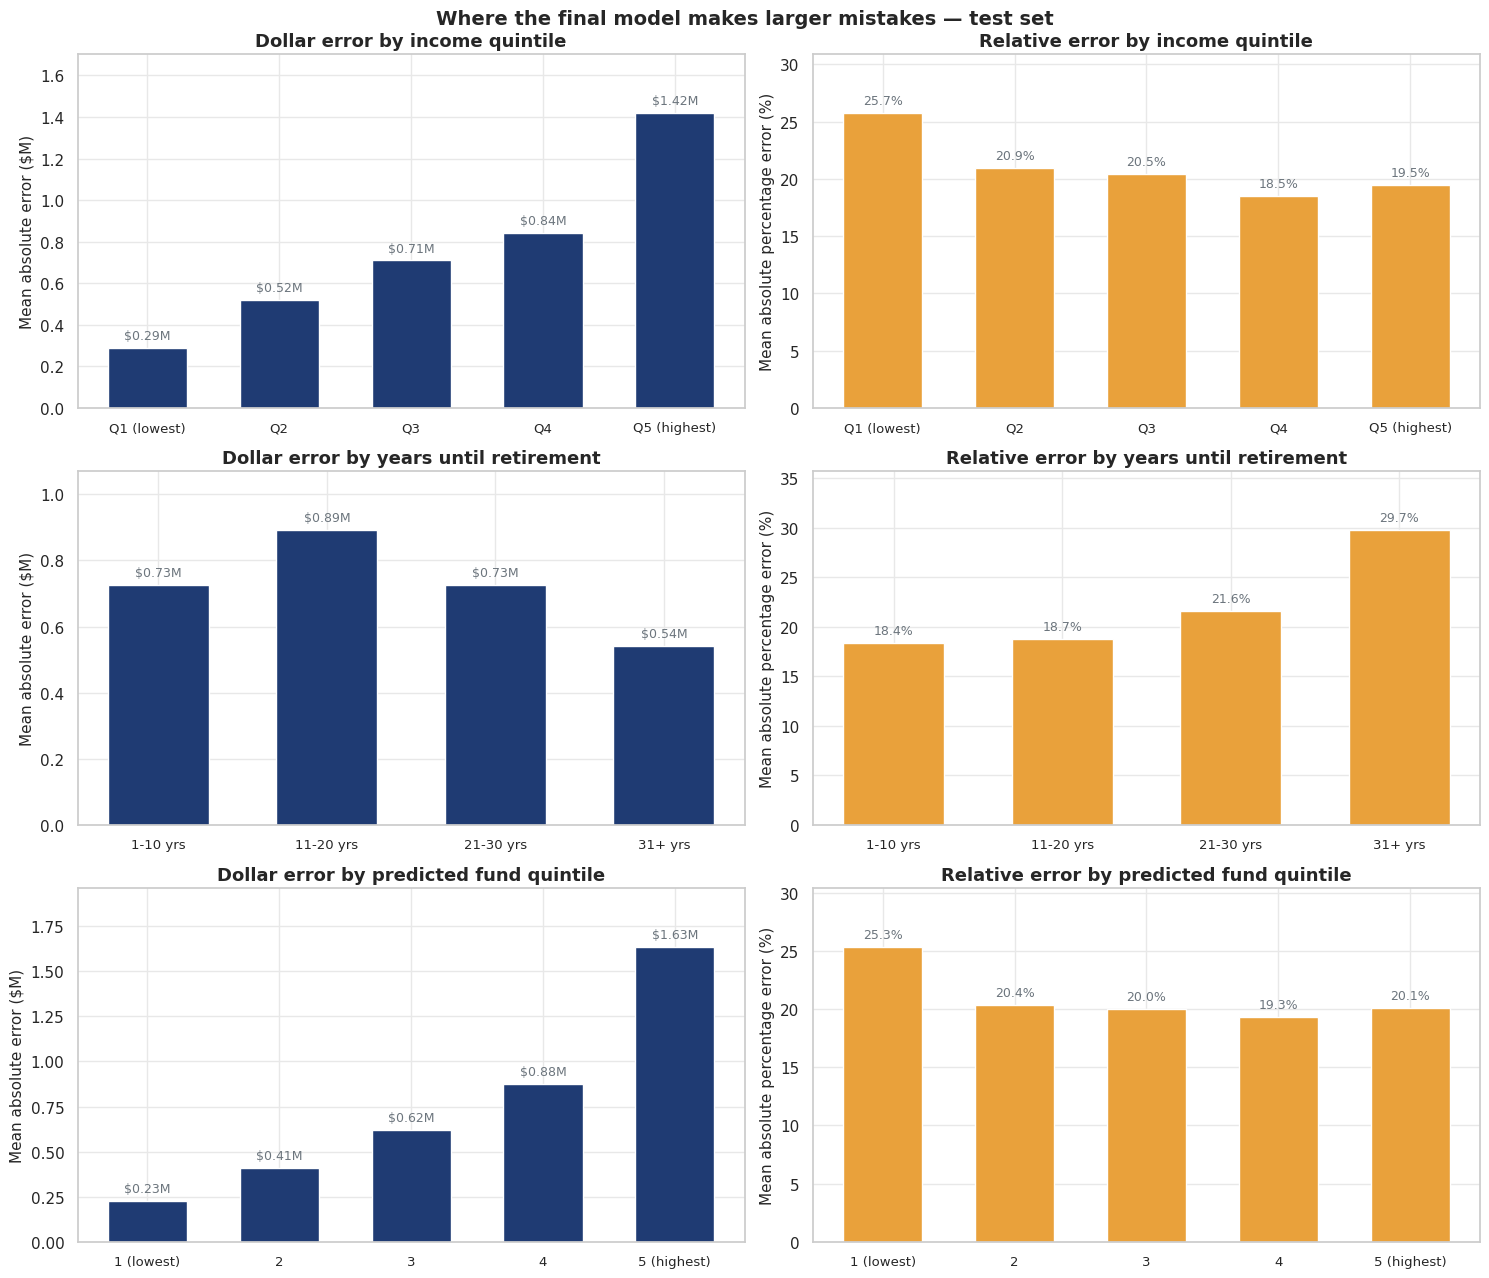

In [ ]:
# --- FIGURE 4: error by segment ------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(15, 13))

segment_titles = {
    "IncomeQuintile": "income quintile",
    "HorizonBand": "years until retirement",
    "PredictedFundQuintile": "predicted fund quintile",
}

for row, (column, summary) in enumerate(segment_summaries.items()):
    positions = np.arange(len(summary))
    label = segment_titles[column]

    axes[row, 0].bar(positions, summary.MAE / 1e6, color=NAVY, edgecolor="white", width=0.6)
    axes[row, 0].set_xticks(positions)
    axes[row, 0].set_xticklabels(summary.index, fontsize=9.5)
    axes[row, 0].set_ylabel("Mean absolute error ($M)")
    axes[row, 0].set_title(f"Dollar error by {label}")
    for position, value in zip(positions, summary.MAE / 1e6):
        axes[row, 0].text(position, value + summary.MAE.max() / 1e6 * 0.03,
                          f"${value:.2f}M", ha="center", fontsize=9, color=SLATE)
    axes[row, 0].set_ylim(0, summary.MAE.max() / 1e6 * 1.2)

    axes[row, 1].bar(positions, summary.MAPE, color=AMBER, edgecolor="white", width=0.6)
    axes[row, 1].set_xticks(positions)
    axes[row, 1].set_xticklabels(summary.index, fontsize=9.5)
    axes[row, 1].set_ylabel("Mean absolute percentage error (%)")
    axes[row, 1].set_title(f"Relative error by {label}")
    for position, value in zip(positions, summary.MAPE):
        axes[row, 1].text(position, value + summary.MAPE.max() * 0.03,
                          f"{value:.1f}%", ha="center", fontsize=9, color=SLATE)
    axes[row, 1].set_ylim(0, summary.MAPE.max() * 1.2)

fig.suptitle("Where the final model makes larger mistakes — test set",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_error_by_segment.png", dpi=300, bbox_inches="tight",
            facecolor="white")
plt.show()

---
## 8. Largest Prediction Errors

### What are we doing?

Identify the customers with the largest prediction errors and inspect their characteristics.

These observations are **not removed**, and the model is **not retrained** after seeing them.

### Why?

Large errors can reveal where the model has difficulty. They can also have a large effect on metrics such as RMSE.

A large prediction error does not automatically mean that the underlying record is incorrect.


In [ ]:
CUSTOMER_CHARACTERISTICS = [
    "Age", "AnnualSalary", "SavingsRate", "RetirementAccountBalance",
    "Retirement_Fund_Goal", "YearsUntilRetirement",
]

largest_errors = errors.nlargest(N_LARGEST_ERRORS, "absolute_error").copy()
for characteristic in CUSTOMER_CHARACTERISTICS:
    largest_errors[characteristic] = X_test_transformed.loc[
        largest_errors.index, characteristic]

largest_errors_table = largest_errors[
    CUSTOMER_CHARACTERISTICS
    + ["actual", "predicted", "absolute_error", "absolute_percentage_error",
       "IncomeQuintile", "HorizonBand"]
]

print(f"The {N_LARGEST_ERRORS} largest absolute errors on the test set:")
print(largest_errors_table.to_string(float_format=lambda value: f"{value:,.2f}"))

print(f"\nThese {N_LARGEST_ERRORS} customers are "
      f"{N_LARGEST_ERRORS / len(errors) * 100:.2f}% of the test set and account for "
      f"{largest_errors.squared_error.sum() / errors.squared_error.sum() * 100:.1f}% "
      f"of the total squared error.")
print(f"Predicted below actual in {int((largest_errors.signed_error < 0).sum())} "
      f"of the {N_LARGEST_ERRORS} rows.")
print(f"Median actual fund among them: ${largest_errors.actual.median():,.0f} "
      f"(test-set median ${errors.actual.median():,.0f})")
print(f"Their median absolute percentage error: "
      f"{largest_errors.absolute_percentage_error.median():.1f}% "
      f"(test-set median {errors.absolute_percentage_error.median():.1f}%)")

The 10 largest absolute errors on the test set:
        Age  AnnualSalary  SavingsRate  RetirementAccountBalance  Retirement_Fund_Goal  YearsUntilRetirement        actual     predicted  absolute_error  absolute_percentage_error IncomeQuintile HorizonBand
5464  48.00    488,485.89         0.16              1,930,683.69          8,190,273.19                 16.00 33,066,937.56 18,904,869.73   14,162,067.83                      42.83   Q5 (highest)   11-20 yrs
29672 51.00    306,798.47         0.11                542,774.14          7,998,811.36                 12.00 20,192,398.31  6,890,348.75   13,302,049.56                      65.88   Q5 (highest)   11-20 yrs
6891  50.00    245,121.98         0.18              6,601,085.28          6,381,231.58                 15.00 31,085,818.17 17,968,058.72   13,117,759.45                      42.20   Q5 (highest)   11-20 yrs
27957 53.00    162,867.52         0.08              3,365,188.05          3,029,867.90                 13.00 19,360,723.32  

---
## 9. Feature Importance Built Into the Model

### What are we doing?

Gradient Boosting provides a built-in feature importance measure called `feature_importances_`.

It summarizes how much each feature contributed to reducing the model's training loss across the 600 trees.

### What does it tell us?

It tells us which transformed features the model relied on more heavily when building its predictions.

It does **not** tell us that those features cause retirement funds to increase.

This distinction is important: **model importance is not causality.**


In [ ]:
builtin_importance = pd.DataFrame({
    "feature": model_feature_names,
    "importance": gradient_boosting.feature_importances_,
}).set_index("feature").sort_values("importance", ascending=False)
builtin_importance["share (%)"] = builtin_importance.importance / builtin_importance.importance.sum() * 100
builtin_importance["cumulative (%)"] = builtin_importance["share (%)"].cumsum()

print(f"Feature names come from the transformed matrix ({len(model_feature_names)} columns),")
print("so the labels below are the columns the estimator actually received.")
print()
print(builtin_importance.head(N_TOP_FEATURES).to_string(
    float_format=lambda value: f"{value:,.4f}"))
print()
print(f"Features with zero importance: {int((builtin_importance.importance == 0).sum())}")
print(f"Share of total importance held by the top 5 features: "
      f"{builtin_importance['share (%)'].head(5).sum():.1f}%")

Feature names come from the transformed matrix (40 columns),
so the labels below are the columns the estimator actually received.

                          importance  share (%)  cumulative (%)
feature                                                        
SalaryBasedContribution       0.5639    56.3909         56.3909
RetirementAccountBalance      0.1025    10.2493         66.6402
InvestmentBalance             0.0829     8.2925         74.9326
YearsUntilRetirement          0.0544     5.4384         80.3711
EmergencyFund                 0.0458     4.5765         84.9476
AnnualSalary                  0.0400     4.0009         88.9485
EmployerPension_Yes           0.0255     2.5511         91.4996
CreditScore                   0.0159     1.5944         93.0940
RiskTolerance                 0.0134     1.3408         94.4348
ExpectedAnnualReturn          0.0120     1.2042         95.6390
Savings                       0.0086     0.8609         96.4999
Retirement_Fund_Goal          0.0083 

---
## 10. Permutation Importance

### What are we doing?

Take one feature at a time, shuffle its values, and measure how much prediction performance changes.

The model itself is not retrained.

If shuffling a feature makes the model's predictions substantially worse, that is evidence that the model was relying on that feature for its predictions.

### Two views of performance

We use both dollar RMSE and log RMSE.

- **Dollar RMSE** gives more weight to large-dollar errors, so large retirement funds can have a strong influence.
- **Log RMSE** puts customers on a more comparable scale and reduces the influence of fund size.

Using both helps us see whether feature importance changes depending on the scale of the error being measured.

This analysis describes the frozen model; it is not used to change it.


In [ ]:
def dollar_rmse_scorer(estimator, X_part, y_part_log):
    """Negative dollar RMSE, following the saved prediction recipe."""
    predicted_dollars = np.exp(estimator.predict(X_part)) * final_config["smearing_factor"]
    actual_dollars = np.exp(y_part_log)
    return -np.sqrt(mean_squared_error(actual_dollars, predicted_dollars))


def log_rmse_scorer(estimator, X_part, y_part_log):
    """Negative RMSE in log space."""
    return -np.sqrt(mean_squared_error(y_part_log, estimator.predict(X_part)))


# The estimator is scored on the transformed matrix, so a permuted column is one
# of the 40 features the model actually sees.
y_test_log_values = y_test_log.to_numpy()

started = time.time()
permutation_dollar = permutation_importance(
    gradient_boosting, X_test_transformed, y_test_log_values,
    scoring=dollar_rmse_scorer, n_repeats=PERMUTATION_REPEATS,
    random_state=RANDOM_STATE, n_jobs=-1,
)
permutation_log = permutation_importance(
    gradient_boosting, X_test_transformed, y_test_log_values,
    scoring=log_rmse_scorer, n_repeats=PERMUTATION_REPEATS,
    random_state=RANDOM_STATE, n_jobs=-1,
)
print(f"Permutation importance computed in {time.time() - started:.0f}s "
      f"({PERMUTATION_REPEATS} repeats, random_state={RANDOM_STATE})")

permutation_results = pd.DataFrame({
    "feature": model_feature_names,
    "RMSE ($) increase": permutation_dollar.importances_mean,
    "RMSE ($) sd": permutation_dollar.importances_std,
    "RMSE (log) increase": permutation_log.importances_mean,
    "RMSE (log) sd": permutation_log.importances_std,
}).set_index("feature").sort_values("RMSE ($) increase", ascending=False)

assert len(permutation_results) == len(model_feature_names)
print()
print(permutation_results.head(N_TOP_FEATURES).to_string(
    float_format=lambda value: f"{value:,.4f}"))
print()
print("Reading: 'RMSE ($) increase' is how much the dollar RMSE grows on average")
print("when that column alone is shuffled. Larger means the model relies on it more.")
print(f"Features whose shuffling changed dollar RMSE by less than its own sd: "
      f"{int((permutation_results['RMSE ($) increase'] < permutation_results['RMSE ($) sd']).sum())}")

Permutation importance computed in 32s (10 repeats, random_state=42)

                          RMSE ($) increase  RMSE ($) sd  RMSE (log) increase  RMSE (log) sd
feature                                                                                     
YearsUntilRetirement         5,342,227.8483 123,546.7354               0.4442         0.0050
RetirementAccountBalance     1,946,643.4308  39,869.9664               0.4580         0.0048
SalaryBasedContribution        686,008.2994  23,093.2333               0.2823         0.0060
InvestmentBalance              222,105.7869  12,394.1928               0.0412         0.0017
Savings                        208,549.2469  11,046.3806               0.0414         0.0021
EmployerPension_Yes            107,355.0344   8,024.0098               0.0478         0.0016
RiskTolerance                   61,155.1894   2,674.5191               0.0070         0.0004
ExpectedAnnualReturn            57,274.1486   4,633.2691               0.0085         0.0007


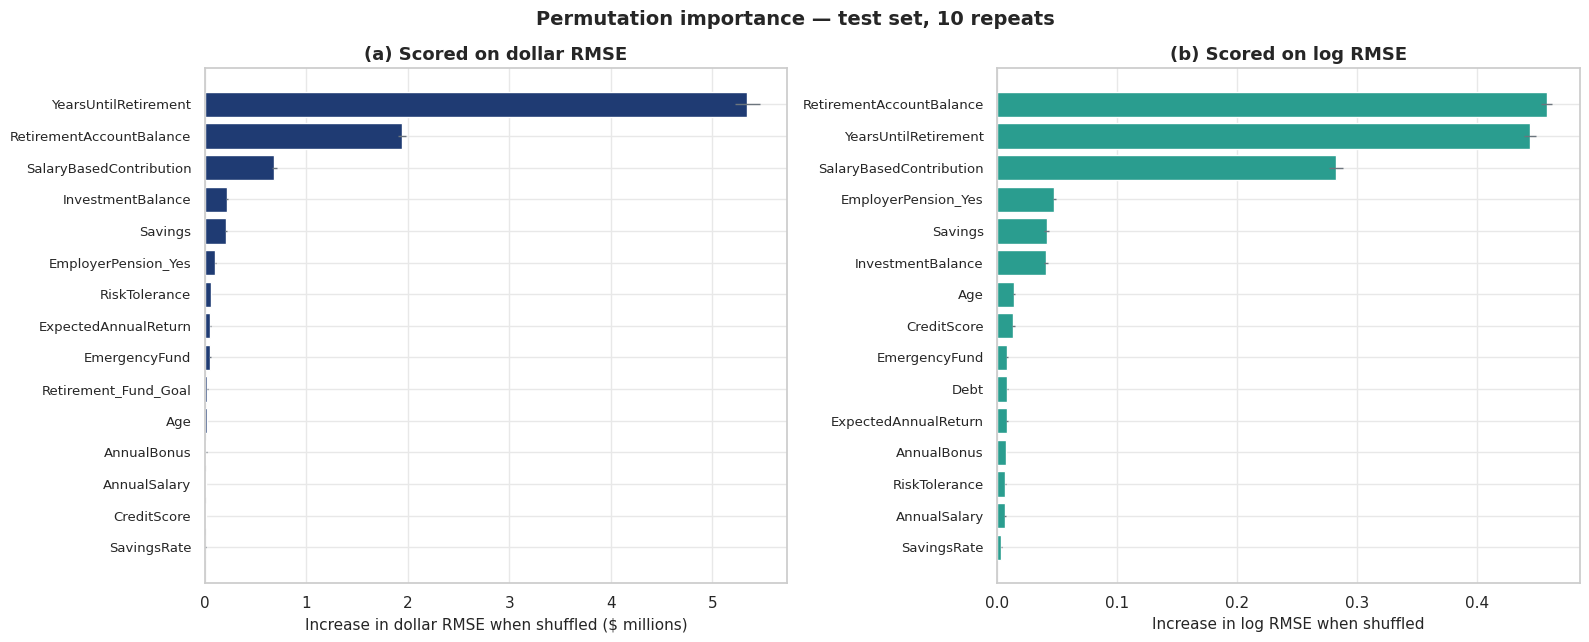

In [ ]:
# --- FIGURE 5: permutation importance ------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

dollar_top = permutation_results.head(N_TOP_FEATURES).iloc[::-1]
positions = np.arange(len(dollar_top))
axes[0].barh(positions, dollar_top["RMSE ($) increase"] / 1e6,
             xerr=dollar_top["RMSE ($) sd"] / 1e6,
             color=NAVY, edgecolor="white", error_kw={"ecolor": SLATE, "lw": 1})
axes[0].set_yticks(positions)
axes[0].set_yticklabels(dollar_top.index, fontsize=9.5)
axes[0].set_xlabel("Increase in dollar RMSE when shuffled ($ millions)")
axes[0].set_title("(a) Scored on dollar RMSE")

log_top = permutation_results.sort_values("RMSE (log) increase", ascending=False)
log_top = log_top.head(N_TOP_FEATURES).iloc[::-1]
positions = np.arange(len(log_top))
axes[1].barh(positions, log_top["RMSE (log) increase"],
             xerr=log_top["RMSE (log) sd"],
             color=TEAL, edgecolor="white", error_kw={"ecolor": SLATE, "lw": 1})
axes[1].set_yticks(positions)
axes[1].set_yticklabels(log_top.index, fontsize=9.5)
axes[1].set_xlabel("Increase in log RMSE when shuffled")
axes[1].set_title("(b) Scored on log RMSE")

fig.suptitle(f"Permutation importance — test set, {PERMUTATION_REPEATS} repeats",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_permutation_importance.png", dpi=300,
            bbox_inches="tight", facecolor="white")
plt.show()

---
## 11. SHAP — Global Explanation

### What are we doing?

SHAP gives a more detailed view of how individual features contribute to model predictions.

The explanation is applied to the **transformed feature matrix** that the Gradient Boosting model actually receives.

This matters because categorical variables were converted into one-hot indicator columns. For example, the model sees `EmployerPension_Yes`, not the original text category by itself.

### What does the SHAP value mean?

The model predicts `log(fund)`, so SHAP values here are also measured in **log space**.

A positive SHAP value pushes a prediction higher than the model's baseline output.

A negative SHAP value pushes it lower.

The size of the SHAP value indicates the strength of that contribution for the prediction being explained.

SHAP describes how this fitted model behaves. It does not establish a real-world causal relationship.


In [ ]:
import shap   # noqa: E402

print("shap", shap.__version__)

started = time.time()
explainer = shap.TreeExplainer(gradient_boosting)
shap_values = explainer.shap_values(X_test_transformed)
shap_base_value = float(np.ravel(explainer.expected_value)[0])
print(f"SHAP values computed in {time.time() - started:.0f}s  shape {shap_values.shape}")

# A tree explainer is exact for this model: base value plus the contributions must
# add back to the model's own log-space prediction.
model_log_predictions = gradient_boosting.predict(X_test_transformed)
additivity_gap = float(np.abs(shap_values.sum(axis=1) + shap_base_value
                              - model_log_predictions).max())

print(f"Base value (mean log prediction): {shap_base_value:.6f}  "
      f"= ${np.exp(shap_base_value) * final_config['smearing_factor']:,.0f} after the recipe")
print(f"Largest additivity gap: {additivity_gap:.3e} (log space)")
print(f"SHAP columns match the model features: "
      f"{shap_values.shape[1] == len(model_feature_names)}")

assert shap_values.shape == (len(X_test_transformed), len(model_feature_names))
assert additivity_gap < 1e-6, "SHAP values do not reconstruct the model's predictions."

/root/nb5env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shap 0.51.0


SHAP values computed in 5s  shape (5970, 40)
Base value (mean log prediction): 14.906477  = $3,063,286 after the recipe
Largest additivity gap: 4.263e-14 (log space)
SHAP columns match the model features: True


In [ ]:
shap_importance = pd.DataFrame({
    "feature": model_feature_names,
    "mean |SHAP| (log)": np.abs(shap_values).mean(axis=0),
    "mean SHAP (log)": shap_values.mean(axis=0),
}).set_index("feature").sort_values("mean |SHAP| (log)", ascending=False)
shap_importance["share (%)"] = (shap_importance["mean |SHAP| (log)"]
                                / shap_importance["mean |SHAP| (log)"].sum() * 100)

print("Global SHAP importance (log-space contributions):")
print(shap_importance.head(N_TOP_FEATURES).to_string(
    float_format=lambda value: f"{value:,.5f}"))
print()
print("The model relies most heavily on these features. That is a statement about")
print("the model, not about what causes a retirement fund to be larger.")
print(f"Top 5 features account for {shap_importance['share (%)'].head(5).sum():.1f}% "
      f"of the total mean absolute contribution.")

Global SHAP importance (log-space contributions):
                          mean |SHAP| (log)  mean SHAP (log)  share (%)
feature                                                                
SalaryBasedContribution             0.27951         -0.00717   20.58617
RetirementAccountBalance            0.26196         -0.01452   19.29341
YearsUntilRetirement                0.25811          0.02505   19.00981
EmployerPension_Yes                 0.10553          0.00104    7.77255
InvestmentBalance                   0.07235         -0.00620    5.32902
Savings                             0.05514         -0.00771    4.06141
EmergencyFund                       0.04787         -0.00474    3.52552
RiskTolerance                       0.03826         -0.00189    2.81786
ExpectedAnnualReturn                0.03800         -0.00224    2.79860
AnnualSalary                        0.02337         -0.00069    1.72122
CreditScore                         0.02273          0.00404    1.67395
Age           

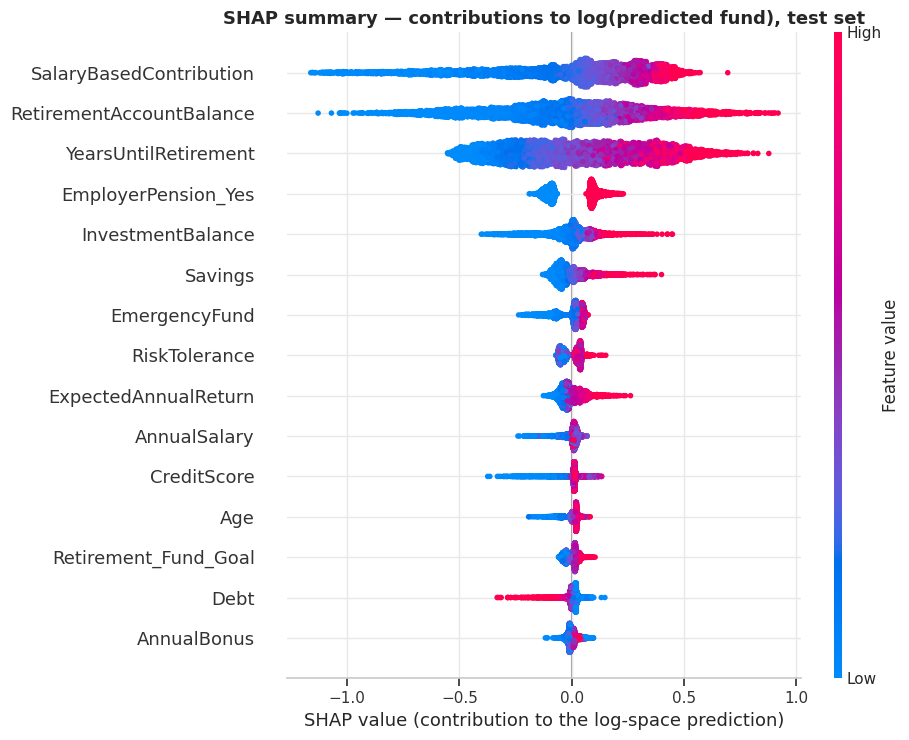

In [ ]:
# --- FIGURE 6: SHAP global summary ---------------------------------------
plt.figure(figsize=(9.5, 7.5))
shap.summary_plot(shap_values, X_test_transformed, max_display=N_TOP_FEATURES,
                  show=False, plot_size=None)
plt.title("SHAP summary — contributions to log(predicted fund), test set",
          fontsize=13, fontweight="bold")
plt.xlabel("SHAP value (contribution to the log-space prediction)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_shap_global.png", dpi=300, bbox_inches="tight",
            facecolor="white")
plt.show()

---
## 12. SHAP — Local Explanations

### What are we doing?

Global importance tells us which features matter across the model as a whole. Local SHAP explanations answer a different question:

> **Why did the model make this particular prediction?**

Five customers are selected using fixed rules, so the same examples are chosen each time the notebook is run.

For each customer, positive SHAP contributions push the prediction higher and negative contributions push it lower.

The contributions are in log space. Because the dollar prediction is calculated as:

`exp(base + contributions) × smearing`

a SHAP contribution of `v` corresponds to a multiplicative factor of `exp(v)` in the dollar prediction. The notebook shows that multiplier to make the log-space contribution easier to interpret.


In [ ]:
# Deterministic selection: nearest predicted value to a fixed percentile, and the
# largest errors. np.argmin and np.argmax return the first match, so ties resolve
# the same way every run.
absolute_errors = errors.absolute_error.to_numpy()
income_quintile_values = errors.IncomeQuintile.to_numpy()

representative_positions = {}
for label, percentile in [("Low prediction (10th pct)", 10),
                          ("Typical prediction (50th pct)", 50),
                          ("High prediction (90th pct)", 90)]:
    target_value = np.percentile(final_test_dollars, percentile)
    representative_positions[label] = int(np.argmin(np.abs(final_test_dollars - target_value)))

representative_positions["Largest absolute error"] = int(np.argmax(absolute_errors))

lowest_income_mask = income_quintile_values == "Q1 (lowest)"
lowest_income_errors = np.where(lowest_income_mask, absolute_errors, -np.inf)
representative_positions["Largest error, lowest income quintile"] = int(np.argmax(lowest_income_errors))

print("Selected test-set positions (deterministic):")
for label, position in representative_positions.items():
    print(f"   {label:<38} row {position:>5}  customer index {X_test_raw.index[position]}")

Selected test-set positions (deterministic):
   Low prediction (10th pct)              row  5790  customer index 12983
   Typical prediction (50th pct)          row  1523  customer index 18983
   High prediction (90th pct)             row  4820  customer index 8985
   Largest absolute error                 row  1193  customer index 5464
   Largest error, lowest income quintile  row  1759  customer index 2533


In [ ]:
N_CONTRIBUTORS = 6   # top positive and top negative contributors shown per customer

local_explanation_rows = []
for label, position in representative_positions.items():
    contributions = pd.Series(shap_values[position], index=model_feature_names)
    ranked = contributions.reindex(contributions.abs().sort_values(ascending=False).index)

    actual = float(errors.actual.iloc[position])
    predicted = float(errors.predicted.iloc[position])

    print("=" * 78)
    print(f"{label}   (customer index {X_test_raw.index[position]})")
    print(f"   actual fund    ${actual:>14,.0f}")
    print(f"   predicted fund ${predicted:>14,.0f}")
    print(f"   error          ${predicted - actual:>+14,.0f}   "
          f"({errors.absolute_percentage_error.iloc[position]:.1f}% of actual)")
    print(f"   base value {shap_base_value:.4f} + contributions "
          f"{contributions.sum():+.4f} = {shap_base_value + contributions.sum():.4f} (log)")

    positive = ranked[ranked > 0].head(N_CONTRIBUTORS)
    negative = ranked[ranked < 0].head(N_CONTRIBUTORS)

    print(f"   pushes the prediction UP:")
    for feature, value in positive.items():
        print(f"      {feature:<30} {value:+.4f} log   x{np.exp(value):.3f}   "
              f"(feature value {X_test_transformed[feature].iloc[position]:,.4g})")
    print(f"   pushes the prediction DOWN:")
    for feature, value in negative.items():
        print(f"      {feature:<30} {value:+.4f} log   x{np.exp(value):.3f}   "
              f"(feature value {X_test_transformed[feature].iloc[position]:,.4g})")

    for feature, value in ranked.head(N_CONTRIBUTORS * 2).items():
        local_explanation_rows.append({
            "example": label,
            "customer_index": X_test_raw.index[position],
            "actual": actual,
            "predicted": predicted,
            "feature": feature,
            "feature_value": float(X_test_transformed[feature].iloc[position]),
            "shap_value_log": float(value),
            "multiplier_on_dollars": float(np.exp(value)),
        })

local_explanations = pd.DataFrame(local_explanation_rows)
print("=" * 78)
print(f"{len(representative_positions)} local explanations created.")

Low prediction (10th pct)   (customer index 12983)
   actual fund    $     1,055,997
   predicted fund $       996,664
   error          $       -59,333   (5.6% of actual)
   base value 14.9065 + contributions -1.1228 = 13.7836 (log)
   pushes the prediction UP:
      Age                            +0.0282 log   x1.029   (feature value 51)
      MortgageBalance                +0.0162 log   x1.016   (feature value 0)
      MonthlyExpenses                +0.0147 log   x1.015   (feature value 4,406)
      CreditScore                    +0.0119 log   x1.012   (feature value 623)
      Debt                           +0.0115 log   x1.012   (feature value 8,418)
      DebtToIncomeRatio              +0.0022 log   x1.002   (feature value 0)
   pushes the prediction DOWN:
      SalaryBasedContribution        -0.2910 log   x0.748   (feature value 4,116)
      RetirementAccountBalance       -0.2877 log   x0.750   (feature value 1.879e+05)
      EmployerPension_Yes            -0.1026 log   x0.903  

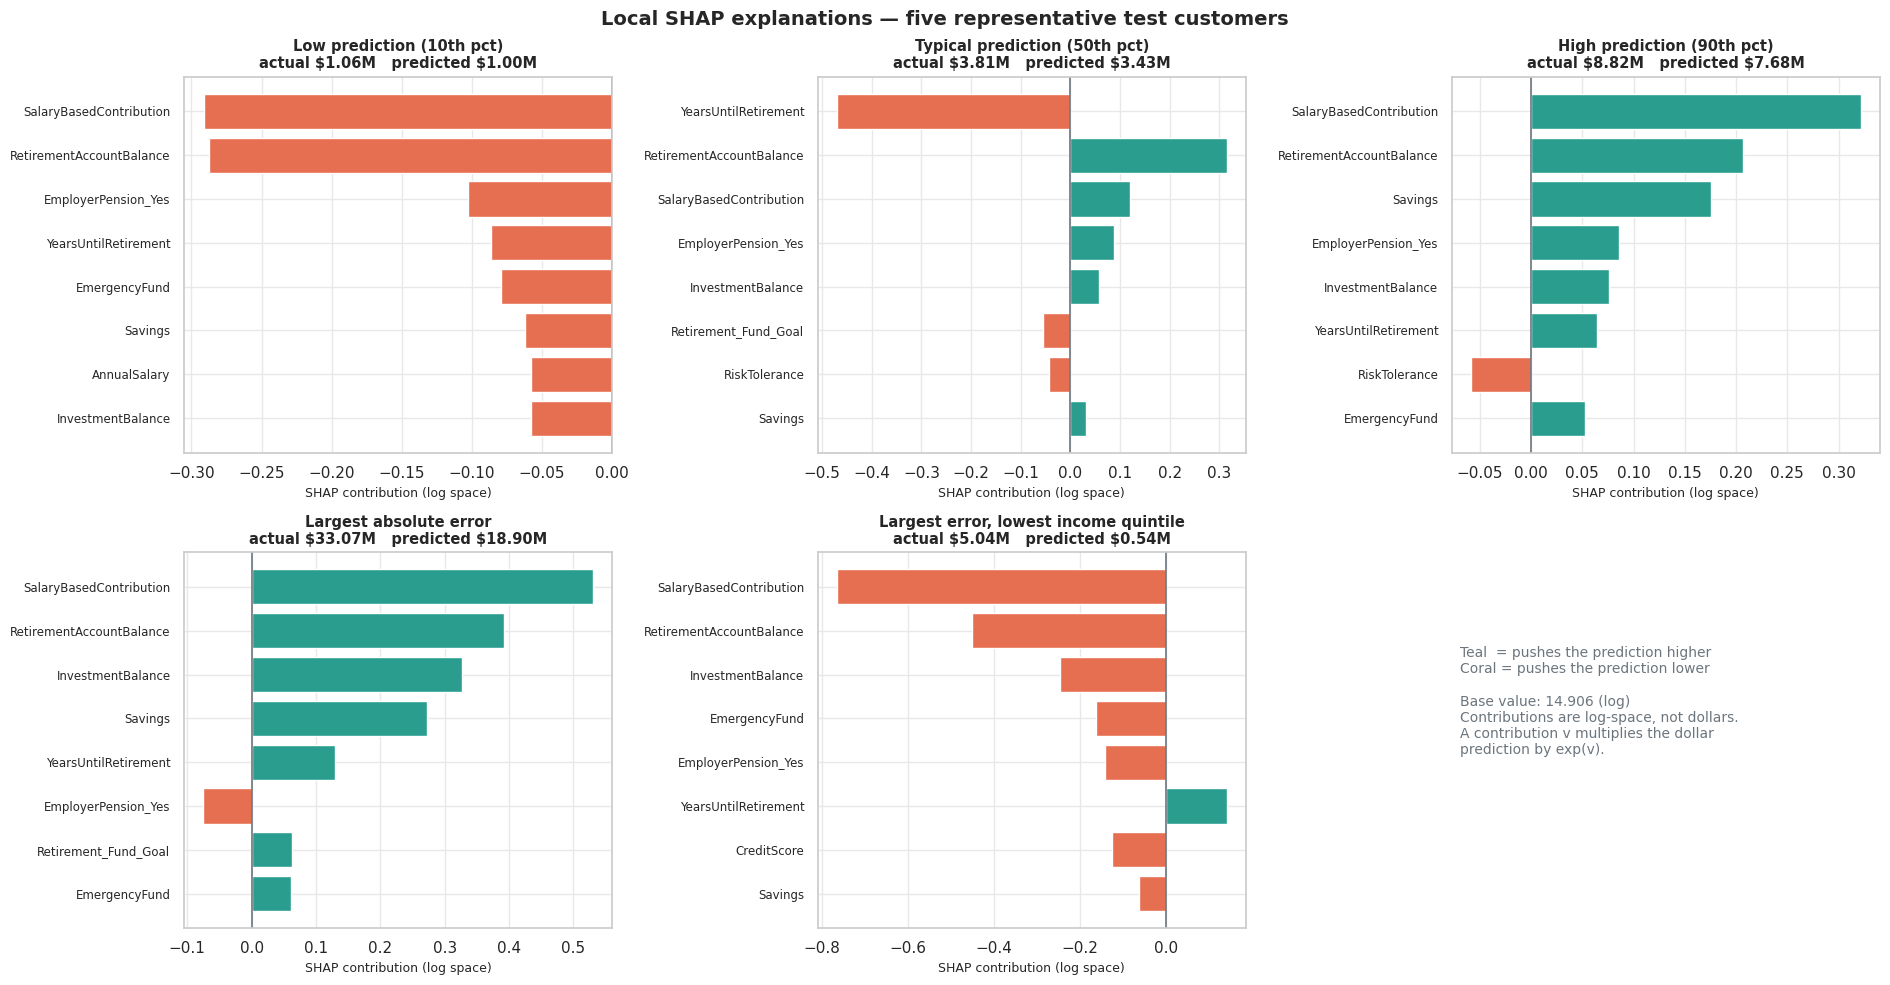

In [ ]:
# --- FIGURE 7: local SHAP explanations -----------------------------------
fig, axes = plt.subplots(2, 3, figsize=(19, 10))
flat_axes = axes.flatten()

for panel, (label, position) in enumerate(representative_positions.items()):
    ax = flat_axes[panel]
    contributions = pd.Series(shap_values[position], index=model_feature_names)
    ranked = contributions.reindex(contributions.abs().sort_values(ascending=False).index)
    top = ranked.head(8).iloc[::-1]

    colours = [TEAL if value > 0 else CORAL for value in top]
    positions = np.arange(len(top))
    ax.barh(positions, top.to_numpy(), color=colours, edgecolor="white")
    ax.axvline(0, color=SLATE, lw=1.2)
    ax.set_yticks(positions)
    ax.set_yticklabels(top.index, fontsize=8.5)
    ax.set_xlabel("SHAP contribution (log space)", fontsize=9)
    # Two dollar signs in one matplotlib string would be read as mathtext, so
    # each one is escaped.
    ax.set_title(f"{label}\n"
                 f"actual \\${errors.actual.iloc[position]/1e6:.2f}M   "
                 f"predicted \\${errors.predicted.iloc[position]/1e6:.2f}M",
                 fontsize=10.5)

flat_axes[-1].axis("off")
flat_axes[-1].text(0.02, 0.75,
                   "Teal  = pushes the prediction higher\n"
                   "Coral = pushes the prediction lower\n\n"
                   f"Base value: {shap_base_value:.3f} (log)\n"
                   "Contributions are log-space, not dollars.\n"
                   "A contribution v multiplies the dollar\n"
                   "prediction by exp(v).",
                   fontsize=10, color=SLATE, va="top")

fig.suptitle("Local SHAP explanations — five representative test customers",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_shap_local.png", dpi=300, bbox_inches="tight",
            facecolor="white")
plt.show()

---
## 13. What the Model Is Using

The three importance methods provide different views:

- **Built-in feature importance** describes how the trees reduced training loss.
- **Permutation importance** measures how much predictive performance changes when a feature is shuffled.
- **SHAP** describes how features contribute to individual model predictions.

The rankings are therefore compared rather than treated as interchangeable measures.

If a feature appears near the top across several methods, that is stronger evidence that the model relies on it. It still does not mean the feature causes the outcome.


In [ ]:
consensus = pd.DataFrame({
    "builtin rank": builtin_importance.importance.rank(ascending=False).astype(int),
    "permutation rank ($)": permutation_results["RMSE ($) increase"].rank(ascending=False).astype(int),
    "permutation rank (log)": permutation_results["RMSE (log) increase"].rank(ascending=False).astype(int),
    "SHAP rank": shap_importance["mean |SHAP| (log)"].rank(ascending=False).astype(int),
})
consensus["mean rank"] = consensus.mean(axis=1)
consensus = consensus.sort_values("mean rank").head(N_TOP_FEATURES)

print(consensus.to_string(float_format=lambda value: f"{value:,.2f}"))
print()
print("Top 5 by each method:")
print(f"   built-in    {', '.join(builtin_importance.head(5).index)}")
print(f"   permutation {', '.join(permutation_results.head(5).index)}")
print(f"   SHAP        {', '.join(shap_importance.head(5).index)}")
print()
print("The rankings differ because dollar RMSE is dominated by the largest funds,")
print("while mean |SHAP| weights every customer equally. Both describe the model's")
print("reliance on a feature. Neither is evidence that the feature causes the fund")
print("to change.")

                          builtin rank  permutation rank ($)  permutation rank (log)  SHAP rank  mean rank
feature                                                                                                   
RetirementAccountBalance             2                     2                       1          2       1.75
SalaryBasedContribution              1                     3                       3          1       2.00
YearsUntilRetirement                 4                     1                       2          3       2.50
InvestmentBalance                    3                     4                       6          5       4.50
EmployerPension_Yes                  7                     6                       4          4       5.25
Savings                             11                     5                       5          6       6.75
EmergencyFund                        5                     9                       9          7       7.50
RiskTolerance                        

---
## 14. Explainability Limitations

Explainability helps us understand the model, but it does not turn model relationships into causal relationships.

- **Feature importance is not causality.** These methods describe what the fitted model uses, not what makes a retirement fund grow.
- **SHAP explains this model.** It does not explain the real financial system represented by the project.
- **Correlated features can share importance.** Engineered features may also overlap with the original columns used to create them.
- **One-hot columns are transformed inputs.** For example, `EmployerPension_Yes` is one model input created from a categorical variable.
- **The dataset is synthetic.** The relationships learned by the model reflect the way this dataset was generated.
- **Segment findings are dataset-specific.** The results describe this test set and should not be treated as evidence about real customers.
- **This is not financial advice.** The analysis describes model behaviour only.


---
## 15. Save Results

### What are we doing?

Save the evaluation results, error analysis, and explainability outputs that are useful outside the notebook.

The saved files provide a record of what the final model did without changing the model itself.


In [ ]:
evaluation_results = pd.DataFrame([baseline_test_scores, final_test_scores]).set_index("Candidate")
evaluation_results.insert(0, "Stage", "Test set")

segment_errors = pd.concat(
    [summary.assign(segmentation=column).rename_axis("segment").reset_index()
     for column, summary in segment_summaries.items()],
    ignore_index=True,
)[["segmentation", "segment", "customers", "median_actual", "MAE", "MedianAE",
   "RMSE", "MAPE", "median_APE", "pct_predicted_below"]]

saved_files = {
    "05_model_evaluation_results.csv": evaluation_results,
    "05_permutation_importance.csv": permutation_results,
    "05_shap_importance.csv": shap_importance,
    "05_error_by_segment.csv": segment_errors,
    "05_largest_errors.csv": largest_errors_table,
    "05_local_explanations.csv": local_explanations,
}

for filename, table in saved_files.items():
    index_wanted = filename != "05_error_by_segment.csv" and filename != "05_local_explanations.csv"
    table.to_csv(ARTIFACTS_DIR / filename, index=index_wanted)

for filename in saved_files:
    path = ARTIFACTS_DIR / filename
    print(f"   {filename:<36} {path.stat().st_size / 1024:>8.1f} KB")

print()
for path in sorted(FIGURES_DIR.glob("05_*.png")):
    print(f"   {path.name:<36} {path.stat().st_size / 1024:>8.1f} KB")

   05_model_evaluation_results.csv           0.5 KB
   05_permutation_importance.csv             3.9 KB
   05_shap_importance.csv                    3.2 KB
   05_error_by_segment.csv                   2.2 KB
   05_largest_errors.csv                     1.6 KB
   05_local_explanations.csv                 7.6 KB

   05_error_by_segment.png                 546.2 KB
   05_final_model_summary.png              328.7 KB
   05_permutation_importance.png           308.2 KB
   05_predicted_vs_actual.png              589.7 KB
   05_residual_analysis.png                759.6 KB
   05_shap_global.png                      518.2 KB
   05_shap_local.png                       570.3 KB


---
## 16. Fresh-Process Reload Test

### What are we checking?

A separate Python process loads the saved model and configuration, imports `src.feature_engineering`, rebuilds the test data from the project files, and generates predictions again.

Those predictions are compared **one by one** with the predictions generated earlier in the notebook.

### Why?

A saved model should not only load successfully; it should reproduce the same predictions when used later in a clean process.


In [ ]:
expected_path = Path(tempfile.gettempdir()) / "05_expected_predictions.npy"
np.save(expected_path, final_test_dollars)

reload_script = '''
import json
import sys

import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

source_root, model_path, config_path, data_path, expected_path = sys.argv[1:6]
sys.path.insert(0, source_root)

# joblib needs this module importable to rebuild the pipeline's feature-engineering
# step; importing it explicitly makes that dependency visible.
from src.feature_engineering import add_engineered_features

model = joblib.load(model_path)
config = json.loads(open(config_path).read())

# The test set is rebuilt from the raw file with the Notebook 2 recipe, so the
# process reproduces the predictions from source rather than from a cached matrix.
raw_data = pd.read_csv(data_path)
features = raw_data.drop(columns=["CustomerID", "Readiness_Score", "Funding_Gap",
                                  "RetirementReady", "Expected_Retirement_Fund"])
target = raw_data["Expected_Retirement_Fund"]
rows_to_keep = ~raw_data.duplicated(keep="first")
_, X_test, _, _ = train_test_split(features[rows_to_keep], target[rows_to_keep],
                                   test_size=0.20, random_state=42)

predictions = model.predict(X_test)
if config["target_scale"] == "log":
    predictions = np.exp(predictions) * config["smearing_factor"]

expected = np.load(expected_path)
print(len(predictions))
print(np.max(np.abs(predictions - expected)))
print(bool(np.array_equal(predictions, expected)))
'''

script_path = Path(tempfile.gettempdir()) / "05_reload_check.py"
script_path.write_text(reload_script)

reload_result = subprocess.run(
    [sys.executable, str(script_path), str(SOURCE_ROOT), str(FINAL_MODEL_PATH),
     str(FINAL_CONFIG_PATH), str(DATA_PATH), str(expected_path)],
    capture_output=True, text=True,
)
if reload_result.returncode != 0:
    raise RuntimeError(f"Reload failed:\n{reload_result.stderr}")

reloaded_count, largest_difference, identical = reload_result.stdout.strip().split("\n")
reloaded_count = int(reloaded_count)
largest_difference = float(largest_difference)
predictions_identical = identical == "True"

print(f"Records predicted in the fresh process: {reloaded_count:,}")
print(f"Bit-identical to this notebook:         {predictions_identical}")
print(f"max|before - after| ($):                {largest_difference:.12f}")
print(f"Tolerance:                              {RELOAD_TOLERANCE:g}")

assert reloaded_count == len(final_test_dollars), "The fresh process predicted a different row count."
assert largest_difference <= RELOAD_TOLERANCE, "Reloaded predictions differ beyond tolerance."

expected_path.unlink()
script_path.unlink()
print("\nFresh-process reload test passed.")

Records predicted in the fresh process: 5,970
Bit-identical to this notebook:         True
max|before - after| ($):                0.000000000000
Tolerance:                              1e-06

Fresh-process reload test passed.


---
## 17. Final Verification

### What are we checking?

The final assertions check that the evaluation and explainability work was completed correctly.

They cover the test data, predictions, feature names, saved results, explainability outputs, and model reload.


In [ ]:
# Re-select the representatives with the same rules to confirm the choice is
# reproducible rather than an artefact of the order things ran in.
recheck_positions = {}
for label, percentile in [("Low prediction (10th pct)", 10),
                          ("Typical prediction (50th pct)", 50),
                          ("High prediction (90th pct)", 90)]:
    target_value = np.percentile(final_test_dollars, percentile)
    recheck_positions[label] = int(np.argmin(np.abs(final_test_dollars - target_value)))
recheck_positions["Largest absolute error"] = int(np.argmax(absolute_errors))
recheck_positions["Largest error, lowest income quintile"] = int(
    np.argmax(np.where(lowest_income_mask, absolute_errors, -np.inf)))

# Evidence that the preprocessing inside the saved model was fitted on the
# training rows and not refitted here: its imputer still holds the training
# medians. This is the same check Notebooks 2 and 3 used.
fitted_column_transformer = final_model.named_steps["preprocess"]
fitted_imputer = fitted_column_transformer.named_transformers_["numeric"].named_steps["impute"]
numeric_columns = fitted_column_transformer.transformers_[0][2]
medians_come_from_training = bool(np.allclose(
    fitted_imputer.statistics_, X_train_raw[numeric_columns].median().to_numpy()))

expected_artifacts = list(saved_files)
expected_figures = ["05_final_model_summary.png", "05_predicted_vs_actual.png",
                    "05_residual_analysis.png", "05_error_by_segment.png",
                    "05_permutation_importance.png", "05_shap_global.png",
                    "05_shap_local.png"]

checks = [
    ("Final model artifact loaded", isinstance(final_model, sklearn.pipeline.Pipeline)),
    ("Configuration loaded", set(final_config) >= {"target_scale", "smearing_factor",
                                                   "model_params", "n_model_features"}),
    ("Final model is fitted", hasattr(gradient_boosting, "estimators_")),
    ("Hyperparameters match the saved configuration",
     all(gradient_boosting.get_params()[key] == value
         for key, value in final_config["model_params"].items())),
    ("Test row count is 5,970", len(X_test_raw) == 5970),
    ("Training row count is 23,880", len(X_train_raw) == 23880),
    ("Raw test columns unchanged (27)", X_test_raw.shape[1] == 27),
    ("Model feature count is 40", len(model_feature_names) == 40),
    ("Feature names come from the transformed matrix, not positions",
     all(isinstance(name, str) and not name.isdigit() for name in model_feature_names)),
    ("Train and test features aligned",
     list(X_train_transformed.columns) == list(X_test_transformed.columns)),
    ("Train and test customers do not overlap",
     len(X_train_raw.index.intersection(X_test_raw.index)) == 0),
    ("Preprocessing is the fitted object from the saved model",
     preprocessor.named_steps["preprocess"] is fitted_column_transformer),
    ("Preprocessing statistics come from the training data",
     medians_come_from_training),
    ("Predictions contain no NaN", not bool(np.isnan(final_test_dollars).any())),
    ("Predictions contain no infinity", bool(np.isfinite(final_test_dollars).all())),
    ("Metrics reproduce Notebook 4 within tolerance",
     largest_reproduction_gap <= REPRODUCTION_TOLERANCE),
    ("Baseline agrees with the Notebook 3 results file", baseline_drift < 1.0),
    ("Baseline and final were scored on the same rows",
     len(baseline_test_dollars) == len(final_test_dollars) == len(test_actual_dollars)),
    ("Improvement figures were calculated, not typed",
     np.isclose(improvements.loc["RMSE ($)", "change (%)"],
                (final_test_scores["RMSE ($)"] / baseline_test_scores["RMSE ($)"] - 1) * 100)),
    ("Residual definition is actual minus predicted",
     np.allclose(residuals_dollars, test_actual_dollars - final_test_dollars)),
    ("Percentage error handles a zero actual safely",
     int(errors.absolute_percentage_error.isna().sum()) == non_positive_actuals),
    ("Segment definitions cover every test customer",
     all(int(errors[column].isna().sum()) == 0 for column in SEGMENT_COLUMNS)),
    ("Permutation importance has one row per model feature",
     len(permutation_results) == len(model_feature_names)),
    ("Permutation importance feature names match the model features",
     sorted(permutation_results.index) == sorted(model_feature_names)),
    ("SHAP produced one value per feature per customer",
     shap_values.shape == (len(X_test_transformed), len(model_feature_names))),
    ("SHAP feature names match the transformed model features",
     list(shap_importance.sort_index().index) == sorted(model_feature_names)),
    ("SHAP values reconstruct the model output", additivity_gap < 1e-6),
    ("Representative customer selection is deterministic",
     recheck_positions == representative_positions),
    ("Five local explanations were created", len(representative_positions) == 5),
    ("Model was not refitted in this notebook",
     gradient_boosting.n_estimators_ == final_config["model_params"]["n_estimators"]),
    ("All result files exist",
     all((ARTIFACTS_DIR / filename).exists() for filename in expected_artifacts)),
    ("All figures exist",
     all((FIGURES_DIR / filename).exists() for filename in expected_figures)),
    ("Saved model reloads in a fresh process", reloaded_count == len(final_test_dollars)),
    ("Reloaded predictions match the originals", largest_difference <= RELOAD_TOLERANCE),
]

verification = pd.DataFrame(checks, columns=["check", "passed"]).set_index("check")
print(verification.to_string())

assert verification.passed.all(), "One or more Notebook 5 checks failed."
print("\nAll verification checks passed.")

                                                               passed
check                                                                
Final model artifact loaded                                      True
Configuration loaded                                             True
Final model is fitted                                            True
Hyperparameters match the saved configuration                    True
Test row count is 5,970                                          True
Training row count is 23,880                                     True
Raw test columns unchanged (27)                                  True
Model feature count is 40                                        True
Feature names come from the transformed matrix, not positions    True
Train and test features aligned                                  True
Train and test customers do not overlap                          True
Preprocessing is the fitted object from the saved model          True
Preprocessing statis

---
## 18. Conclusion / Next Step

### What did this notebook establish?

We evaluated the final Notebook 4 model on the untouched test set, compared it with the original baseline, examined its errors, and used three complementary methods to understand what the model relies on.

The main distinction to keep in mind is:

> **Performance tells us how well the model predicts. Explainability helps us understand how the model arrives at those predictions. Neither establishes causality.**

The evaluation and explainability results have been saved under `artifacts/` and `figures/`.

### Next step

The model is now trained, improved, evaluated, and explained. The next stage can focus on turning the model into a more complete retirement-readiness workflow and deciding how its predictions should be presented and used.


---
## 18. Conclusion / Next Step

### Conclusion

The final Gradient Boosting model was evaluated on the untouched test set and compared with the original Notebook 3 baseline. The final model reduced dollar RMSE and improved the other main performance measures, while the error analysis showed that performance is not identical across all customer groups.

The explainability analysis also showed which features the model relies on and how those features contribute to individual predictions. These explanations describe the behaviour of the trained model; they do not establish causal relationships.

The dataset is synthetic, so these results should be treated as a demonstration of the machine-learning workflow rather than evidence about real retirement outcomes.

### Next step

The modeling pipeline is now complete: the data has been explored and prepared, a baseline has been established, the model has been improved, and the final model has been evaluated and explained.

The next stage should move from model development to the financial application of the model — turning the predicted retirement fund into useful measures such as a funding gap, retirement readiness, or required savings level.



In [ ]:
print("Final model:", final_config["candidate"])
print(f"   {final_config['model_params']}")
print(f"   prediction recipe: exp(log prediction) x "
      f"{final_config['smearing_factor']:.6f} (smearing)")
print()
print(f"Test-set performance ({len(X_test_raw):,} customers):")
for metric in ["R2 (log)", "R2 ($)", "RMSE ($)", "MAE ($)", "MedianAE ($)", "MAPE (%)"]:
    print(f"   {metric:<14} {final_test_scores[metric]:>16,.4f}")
print()
print(f"vs the Notebook 3 baseline:")
for metric in ["RMSE ($)", "MAE ($)", "MedianAE ($)"]:
    print(f"   {metric:<14} {improvements.loc[metric, 'change (%)']:>+8.2f}%")
print()
print(f"Largest relative gap vs the Notebook 4 record: {largest_reproduction_gap:.2e}")
print(f"Most relied-on features (mean |SHAP|): "
      f"{', '.join(shap_importance.head(3).index)}")
print(f"Most relied-on features (permutation, dollar RMSE): "
      f"{', '.join(permutation_results.head(3).index)}")
print()
print("The model was not changed in this notebook. Anything surprising in the")
print("explainability results is recorded as a finding for a later stage, not")
print("acted on here.")

Final model: Tuned GB (log + smearing)
   {'subsample': 0.8, 'n_estimators': 600, 'min_samples_leaf': 5, 'max_depth': 4, 'learning_rate': 0.05}
   prediction recipe: exp(log prediction) x 1.028933 (smearing)

Test-set performance (5,970 customers):
   R2 (log)                 0.9022
   R2 ($)                   0.8515
   RMSE ($)         1,231,162.9358
   MAE ($)            753,165.4836
   MedianAE ($)       436,661.8044
   MAPE (%)                21.0147

vs the Notebook 3 baseline:
   RMSE ($)          -2.77%
   MAE ($)           -2.15%
   MedianAE ($)      -2.68%

Largest relative gap vs the Notebook 4 record: 2.22e-16
Most relied-on features (mean |SHAP|): SalaryBasedContribution, RetirementAccountBalance, YearsUntilRetirement
Most relied-on features (permutation, dollar RMSE): YearsUntilRetirement, RetirementAccountBalance, SalaryBasedContribution

The model was not changed in this notebook. Anything surprising in the
explainability results is recorded as a finding for a later stag